In [1]:
import torch
import numpy as np
import pandas as pd

emb = torch.load(
    "embeddings/fold_4_embeddings.pt"
)

tissue_emb = emb["epoch99"]["tissue"]
plasma_emb = emb["epoch99"]["plasma"]


patients = sorted(
    set(tissue_emb.keys()) &
    set(plasma_emb.keys())
)

print(len(patients))

10


In [59]:
print(tissue_emb.keys())

dict_keys(['Sample 20', 'Sample 24', 'Sample 30', 'Sample 36', 'Sample 39', 'Sample 45', 'Sample 55', 'Sample 72', 'Sample 77', 'Sample 90'])


In [2]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import matplotlib.cm as cm
def plot(pca_df, fold, proj = False, epoch=0):
    patients = sorted(
    set(pca_df["patient"])
    )

    # Create a color mapping for patients
    colors = cm.get_cmap("tab20", len(patients))
    patient_colors = {
        patient: colors(i)
        for i, patient in enumerate(patients)
    }

    plt.figure(figsize=(7,6))



    for patient in patients:

        color = patient_colors[patient]

        tissue = pca_df[
        (pca_df["patient"] == patient) &
        (pca_df["modality"] == "Tissue")
        ].iloc[0]

        plasma = pca_df[
        (pca_df["patient"] == patient) &
        (pca_df["modality"] == "Plasma")
        ].iloc[0]

        t = tissue[["PC1", "PC2"]].values
        p = plasma[["PC1", "PC2"]].values


        plt.scatter(
            t[0],
            t[1],
            marker="o",
            color = color,
            label="Tissue" if patient == patients[0] else ""
        )

        plt.scatter(
            p[0],
            p[1],
            marker="^",
            color=color,
            label="Plasma" if patient == patients[0] else ""

        )


        plt.plot(
            [t[0],p[0]],
            [t[1],p[1]],
            color=color,
            alpha=0.3
        )

    if proj == True:
        emb_type = 'projected embedding'
    else:
        emb_type = 'encoded embedding'
    plt.title(
        f"Patient-wise tissue-plasma {emb_type} alignment after {epoch} epochs"
    )
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend()


    # plt.savefig(f'embeddings/plots/embeddings_fold_{fold}_{epoch}_{emb_type}.png',
    #     bbox_inches="tight")
    plt.show()




In [3]:
def compute_PCA(plasma_emb, tissue_emb):
    X = []
    labels = []
    modalities = []
    patients = sorted(
        set(tissue_emb.keys()) &
        set(plasma_emb.keys())
    )

    for patient in patients:

        X.append(
            tissue_emb[patient].numpy()
        )
        labels.append(patient)
        modalities.append("Tissue")


        X.append(
            plasma_emb[patient].numpy()
        )
        labels.append(patient)
        modalities.append("Plasma")


    X = np.stack(X)
    pca = PCA(
        n_components=2
    )

    X_pca = pca.fit_transform(X)
    pca_df = pd.DataFrame({
    "patient": labels,
    "modality": modalities,
    "PC1": X_pca[:,0],
    "PC2": X_pca[:,1]
})
    return pca, pca_df


In [4]:
def paired_distances_per_pc(pca_df):

    pc_cols = [c for c in pca_df.columns if c.startswith("PC")]

    results = []

    for pc in pc_cols:

        distances = []

        for patient in pca_df["patient"].unique():

            tissue = pca_df[
                (pca_df.patient == patient) &
                (pca_df.modality == "Tissue")
            ][pc].values[0]

            plasma = pca_df[
                (pca_df.patient == patient) &
                (pca_df.modality == "Plasma")
            ][pc].values[0]

            distances.append(abs(tissue - plasma))

        results.append({
            "PC": pc,
            "mean_distance": np.mean(distances),
            "std_distance": np.std(distances)
        })

    return pd.DataFrame(results)

In [5]:
def modality_separation(pca_df):

    pc_cols = [c for c in pca_df.columns if c.startswith("PC")]

    results = []

    for pc in pc_cols:

        tissue_values = pca_df[
            pca_df["modality"] == "Tissue"
        ][pc]

        plasma_values = pca_df[
            pca_df["modality"] == "Plasma"
        ][pc]

        separation = abs(
            tissue_values.mean() -
            plasma_values.mean()
        )

        results.append({
            "PC": pc,
            "modality_separation": separation,
            "tissue_mean": tissue_values.mean(),
            "plasma_mean": plasma_values.mean()
        })

    return pd.DataFrame(results)

In [11]:
def visualize_embeddings(proj=False, trained = True):
    all_pc_distances = []
    all_pc_separations = []
    all_variance =[]
    pc_all_folds ={}

    for fold in range(5):
        if proj:
            emb = torch.load(
            f"embeddings/fold_{fold}_embeddings_proj.pt"
            )
        else:
            emb = torch.load(
            f"embeddings/fold_{fold}_embeddings.pt"
            )

        tissue_emb_0 = emb["epoch0"]["tissue"]
        plasma_emb_0 = emb["epoch0"]["plasma"]

        tissue_emb_99 = emb["epoch99"]["tissue"]
        plasma_emb_99 = emb["epoch99"]["plasma"]


        pca_0, pca_0_df = compute_PCA(plasma_emb_0, tissue_emb_0)
        pca_99, pca_99_df = compute_PCA(plasma_emb_99, tissue_emb_99)


        from sklearn.metrics import roc_auc_score
        if trained == True:
            pca_99_df['fold']= fold
            pc_all_folds[fold] = pca_99_df.copy()
            for pc in ["PC1", "PC2"]:

                values = pca_99_df[pc].values

                labels = (
                    pca_99_df["modality"] == "Plasma"
                ).astype(int)

                auc = roc_auc_score(labels, values)

                print(pc, auc)


            distance = paired_distances_per_pc(pca_99_df)
            distance["fold"] = fold
            print(f'Distances Fold {fold}')
            print(distance)

            all_pc_distances.append(distance)

            separation = modality_separation(pca_99_df)
            separation["fold"] = fold

            print(f"Fold {fold} separation")
            print(separation)
            all_pc_separations.append(separation)

            explained_variance = pd.DataFrame({
            "PC": [f"PC{i+1}" for i in range(len(pca_99.explained_variance_ratio_))],
            "explained_variance": pca_99.explained_variance_ratio_,
            "fold": fold
            })

            all_variance.append(explained_variance)

            plt.bar(
            range(1,3),
            pca_99.explained_variance_ratio_,
            )
            plt.title(f'explained variance ratio for fold {fold}')
            plt.xlabel("PC")
            plt.ylabel("Explained variance")
            plt.show()
            plot(pca_0_df, fold=fold, proj=proj,epoch=0)
            plot(pca_99_df,fold=fold, proj=proj,epoch=99)

        else:
            pca_0_df['fold']= fold
            pc_all_folds[fold] = pca_0_df.copy()
            for pc in ["PC1", "PC2"]:

                values = pca_0_df[pc].values

                labels = (
                    pca_0_df["modality"] == "Plasma"
                ).astype(int)

                auc = roc_auc_score(labels, values)

                print(pc, auc)


            distance = paired_distances_per_pc(pca_0_df)
            distance["fold"] = fold
            print(f'Distances Fold {fold}')
            print(distance)

            all_pc_distances.append(distance)

            separation = modality_separation(pca_0_df)
            separation["fold"] = fold

            print(f"Fold {fold} separation")
            print(separation)
            all_pc_separations.append(separation)

            explained_variance = pd.DataFrame({
            "PC": [f"PC{i+1}" for i in range(len(pca_0.explained_variance_ratio_))],
            "explained_variance": pca_0.explained_variance_ratio_,
            "fold": fold
            })

            all_variance.append(explained_variance)

            plt.bar(
            range(1,3),
            pca_0.explained_variance_ratio_,
            )
            plt.title(f'explained variance ratio for fold {fold}')
            plt.xlabel("PC")
            plt.ylabel("Explained variance")
            plt.show()
            plot(pca_0_df, fold=fold, proj=proj,epoch=0)
            plot(pca_99_df,fold=fold, proj=proj,epoch=99)

    all_pc_distances = pd.concat(
    all_pc_distances,
    ignore_index=True
     )
    all_pc_separations = pd.concat(all_pc_separations,ignore_index=True)
    all_variance = pd.concat(all_variance,ignore_index=True)

    pc_all_folds_df = pd.concat(
    pc_all_folds.values(),
    ignore_index=True
    )
    print(pc_all_folds_df)
    return pc_all_folds_df, all_pc_distances, all_pc_separations, all_variance





PC1 1.0
PC2 0.45454545454545453
Distances Fold 0
    PC  mean_distance  std_distance  fold
0  PC1       2.054491      0.076721     0
1  PC2       0.573834      0.303596     0
Fold 0 separation
    PC  modality_separation  tissue_mean  plasma_mean  fold
0  PC1             2.054491    -1.027246     1.027246     0
1  PC2             0.100898     0.050449    -0.050449     0


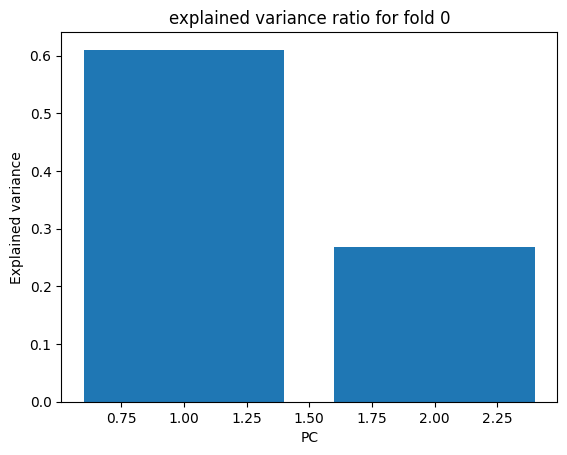

/home/bmep/plalfken/tmp/ipykernel_535847/785534770.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab20", len(patients))


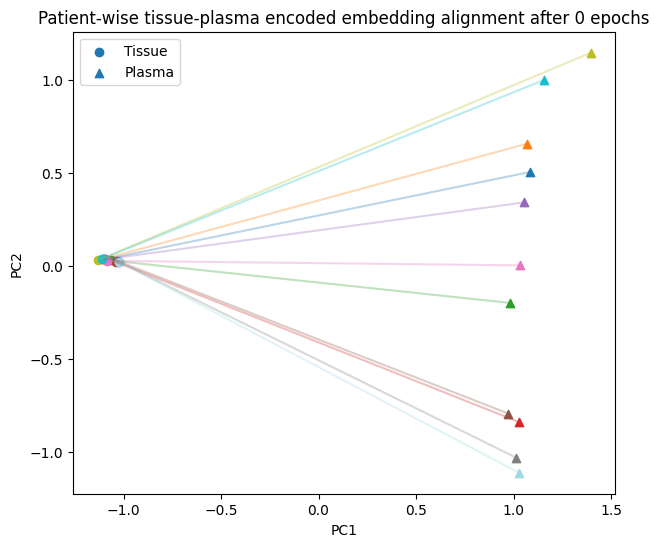

/home/bmep/plalfken/tmp/ipykernel_535847/785534770.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab20", len(patients))


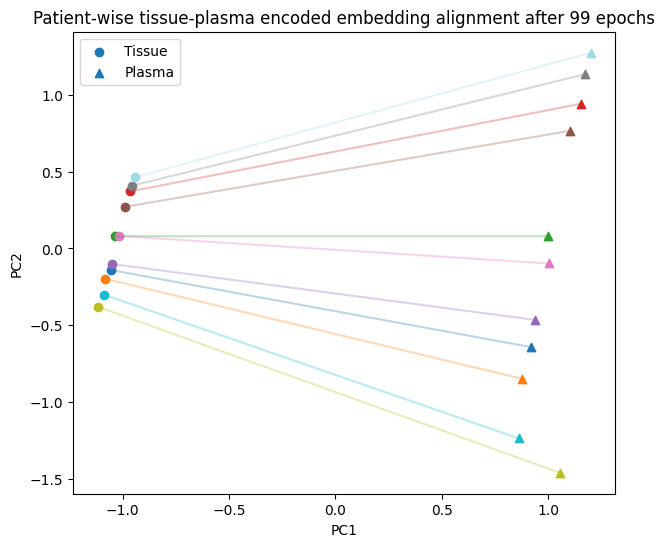

PC1 1.0
PC2 0.5041322314049587
Distances Fold 1
    PC  mean_distance  std_distance  fold
0  PC1       2.222552      0.287422     1
1  PC2       0.298484      0.152715     1
Fold 1 separation
    PC  modality_separation  tissue_mean  plasma_mean  fold
0  PC1             2.222552    -1.111276     1.111276     1
1  PC2             0.137170    -0.068585     0.068585     1


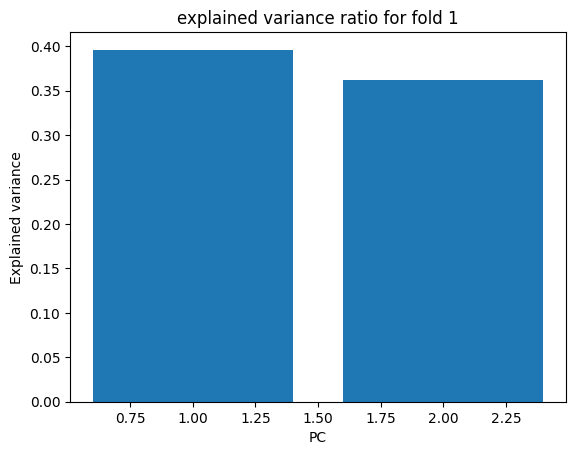

/home/bmep/plalfken/tmp/ipykernel_535847/785534770.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab20", len(patients))


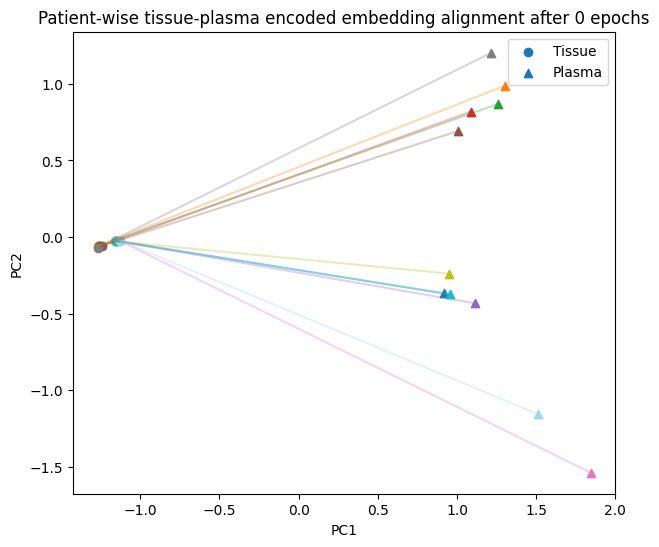

/home/bmep/plalfken/tmp/ipykernel_535847/785534770.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab20", len(patients))


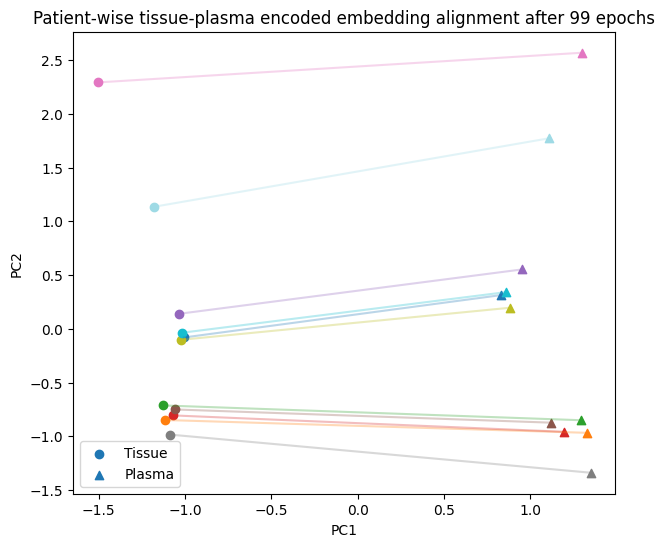

PC1 1.0
PC2 0.6
Distances Fold 2
    PC  mean_distance  std_distance  fold
0  PC1       2.171693      0.125998     2
1  PC2       0.652021      0.419667     2
Fold 2 separation
    PC  modality_separation  tissue_mean  plasma_mean  fold
0  PC1             2.171693    -1.085847     1.085846     2
1  PC2             0.092978    -0.046489     0.046489     2


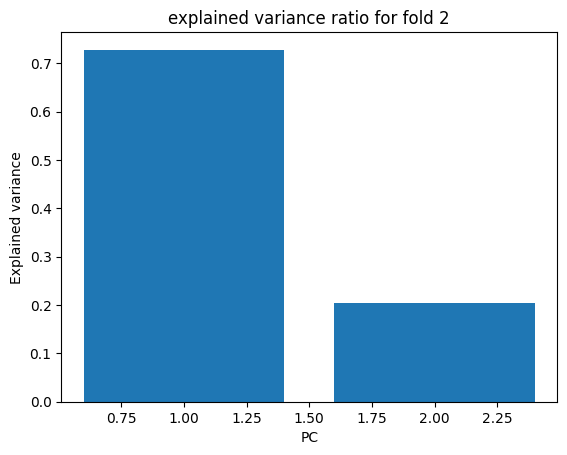

/home/bmep/plalfken/tmp/ipykernel_535847/785534770.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab20", len(patients))


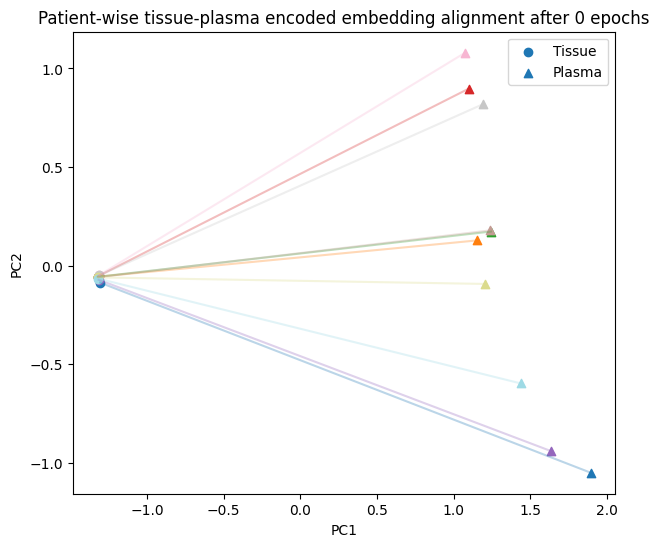

/home/bmep/plalfken/tmp/ipykernel_535847/785534770.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab20", len(patients))


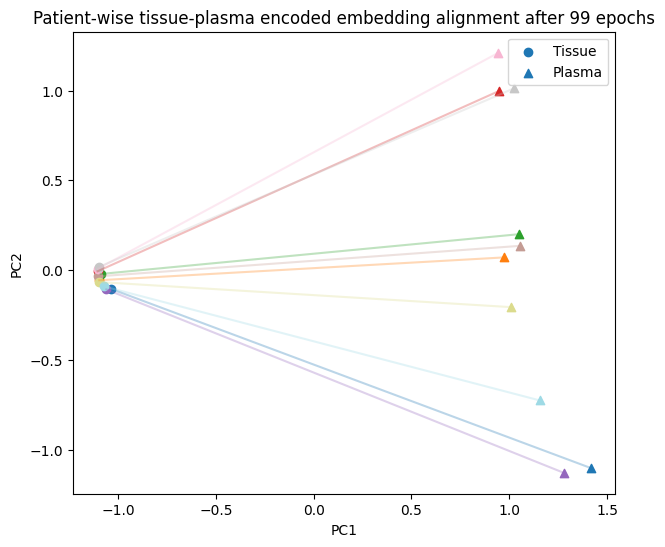

PC1 1.0
PC2 0.4
Distances Fold 3
    PC  mean_distance  std_distance  fold
0  PC1       2.376935      0.136578     3
1  PC2       0.723256      0.309087     3
Fold 3 separation
    PC  modality_separation  tissue_mean  plasma_mean  fold
0  PC1             2.376936    -1.188468     1.188468     3
1  PC2             0.019872    -0.009936     0.009936     3


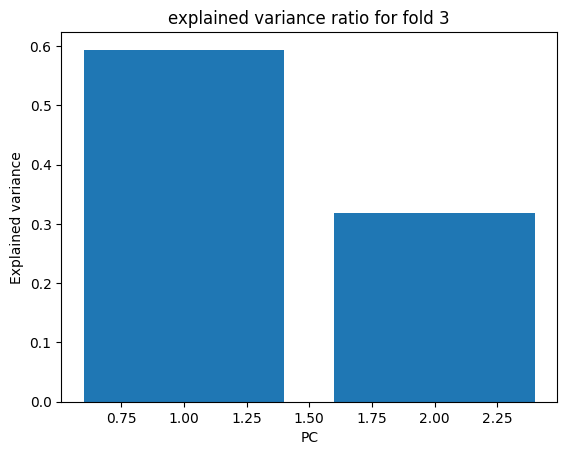

/home/bmep/plalfken/tmp/ipykernel_535847/785534770.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab20", len(patients))


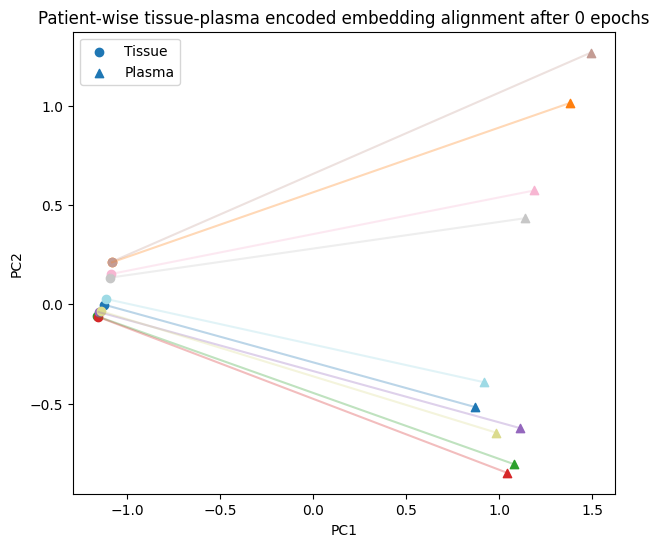

/home/bmep/plalfken/tmp/ipykernel_535847/785534770.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab20", len(patients))


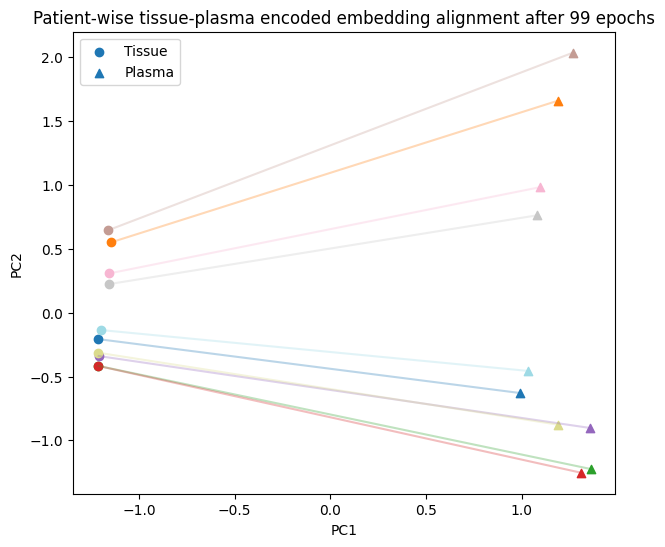

PC1 1.0
PC2 0.68
Distances Fold 4
    PC  mean_distance  std_distance  fold
0  PC1       2.296628      0.719429     4
1  PC2       0.751479      0.862283     4
Fold 4 separation
    PC  modality_separation  tissue_mean  plasma_mean  fold
0  PC1             2.296628    -1.148314     1.148314     4
1  PC2             0.751479    -0.375739     0.375739     4


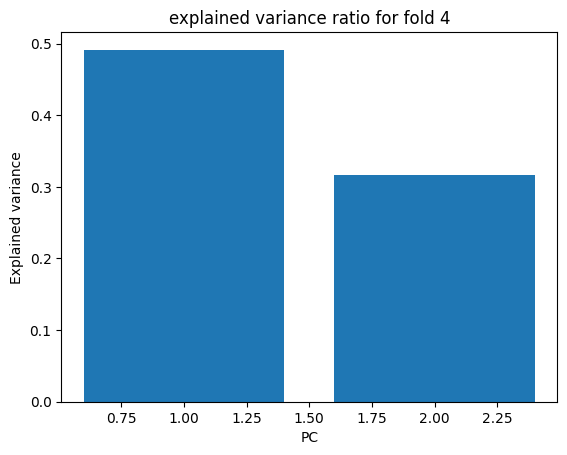

/home/bmep/plalfken/tmp/ipykernel_535847/785534770.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab20", len(patients))


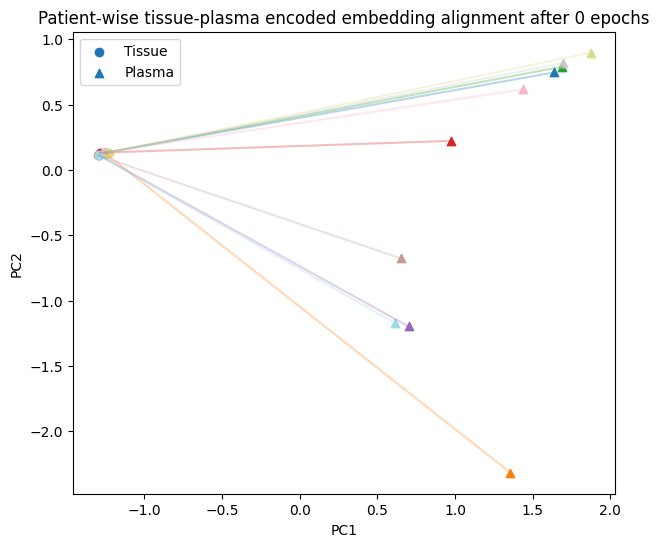

/home/bmep/plalfken/tmp/ipykernel_535847/785534770.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab20", len(patients))


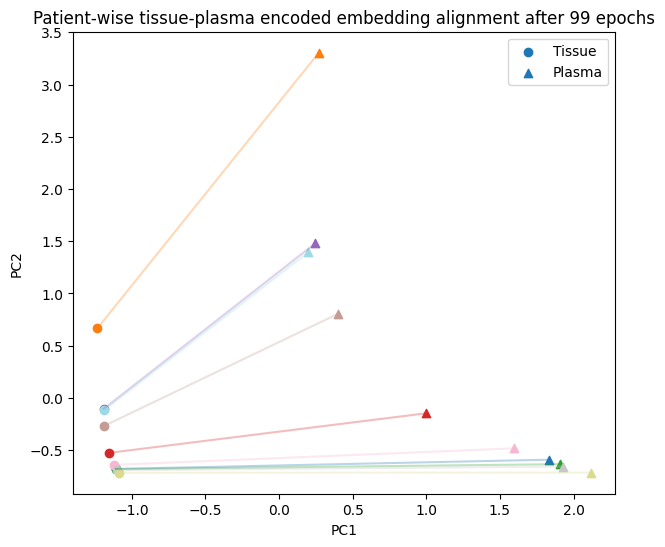

       patient modality       PC1       PC2  fold
0    Sample 15   Tissue -1.055641 -0.140609     0
1    Sample 15   Plasma  0.921344 -0.642128     0
2    Sample 17   Tissue -1.081169 -0.197666     0
3    Sample 17   Plasma  0.878996 -0.848706     0
4    Sample 28   Tissue -1.035897  0.079331     0
..         ...      ...       ...       ...   ...
99   Sample 72   Plasma  1.928520 -0.656913     4
100  Sample 77   Tissue -1.088467 -0.715771     4
101  Sample 77   Plasma  2.115916 -0.714638     4
102  Sample 90   Tissue -1.189394 -0.118239     4
103  Sample 90   Plasma  0.195885  1.393103     4

[104 rows x 5 columns]


In [98]:
pc, all_distances, all_separations, all_variance = visualize_embeddings(proj=False, trained=True)

In [99]:
print(pc.head())

     patient modality       PC1       PC2  fold
0  Sample 15   Tissue -1.055641 -0.140609     0
1  Sample 15   Plasma  0.921344 -0.642128     0
2  Sample 17   Tissue -1.081169 -0.197666     0
3  Sample 17   Plasma  0.878996 -0.848706     0
4  Sample 28   Tissue -1.035897  0.079331     0


In [100]:
summary_df = (
    all_distances
    .groupby("PC")
    .agg(
        mean_distance_across_folds=("mean_distance", "mean"),
        std_distance_across_folds=("std_distance", "mean")

    )
    .reset_index()
)

print(summary_df)

    PC  mean_distance_across_folds  std_distance_across_folds
0  PC1                    2.224460                    0.26923
1  PC2                    0.599815                    0.40947


In [101]:
summary_df_2 = all_separations.groupby("PC").agg(
        mean_separation_across_folds=("modality_separation", "mean")).reset_index()


print(summary_df_2)

    PC  mean_separation_across_folds
0  PC1                      2.224460
1  PC2                      0.220479


In [102]:
print(all_distances)

    PC  mean_distance  std_distance  fold
0  PC1       2.054491      0.076721     0
1  PC2       0.573834      0.303596     0
2  PC1       2.222552      0.287422     1
3  PC2       0.298484      0.152715     1
4  PC1       2.171693      0.125998     2
5  PC2       0.652021      0.419667     2
6  PC1       2.376935      0.136578     3
7  PC2       0.723256      0.309087     3
8  PC1       2.296628      0.719429     4
9  PC2       0.751479      0.862283     4


In [103]:
variance_summary = (
    all_variance
    .groupby("PC")
    .agg(
        mean_variance=("explained_variance", "mean"),
        std_variance=("explained_variance", "std")
    )
    .reset_index()
)

print(variance_summary)

    PC  mean_variance  std_variance
0  PC1       0.563951      0.126033
1  PC2       0.293889      0.060285


In [104]:
tissue_scores = pd.read_csv('PR80_30/tissue_pathway_scores.csv')
plasma_scores = pd.read_csv('PR80_30/plasma_pathway_scores.csv')

In [105]:
tissue_scores.columns

Index(['Name', 'REACTOME_ABC_FAMILY_PROTEINS_MEDIATED_TRANSPORT',
       'REACTOME_ABC_TRANSPORTER_DISORDERS',
       'REACTOME_ABORTIVE_ELONGATION_OF_HIV_1_TRANSCRIPT_IN_THE_ABSENCE_OF_TAT',
       'REACTOME_ACTIVATION_OF_AMPK_DOWNSTREAM_OF_NMDARS',
       'REACTOME_ACTIVATION_OF_ANTERIOR_HOX_GENES_IN_HINDBRAIN_DEVELOPMENT_DURING_EARLY_EMBRYOGENESIS',
       'REACTOME_ACTIVATION_OF_APC_C_AND_APC_C_CDC20_MEDIATED_DEGRADATION_OF_MITOTIC_PROTEINS',
       'REACTOME_ACTIVATION_OF_BH3_ONLY_PROTEINS',
       'REACTOME_ACTIVATION_OF_GENE_EXPRESSION_BY_SREBF_SREBP',
       'REACTOME_ACTIVATION_OF_NF_KAPPAB_IN_B_CELLS',
       ...
       'REACTOME_UBIQUITIN_DEPENDENT_DEGRADATION_OF_CYCLIN_D',
       'REACTOME_UBIQUITIN_MEDIATED_DEGRADATION_OF_PHOSPHORYLATED_CDC25A',
       'REACTOME_UB_SPECIFIC_PROCESSING_PROTEASES', 'REACTOME_UCH_PROTEINASES',
       'REACTOME_UNFOLDED_PROTEIN_RESPONSE_UPR',
       'REACTOME_VASOPRESSIN_REGULATES_RENAL_WATER_HOMEOSTASIS_VIA_AQUAPORINS',
       'REACTOME_VEGFR

In [106]:
tissue_pc = pc[
    pc["modality"] == "Tissue"
]
print(tissue_pc.head())
plasma_pc = pc[pc['modality'] == 'Plasma']
print(plasma_pc.head())
tissue_scores = tissue_scores.rename(columns={"Name": "patient"})
plasma_scores = plasma_scores.rename(columns={"Name": "patient"})

merged_plasma = plasma_pc.merge(
    plasma_scores,
    on="patient",
    how="inner"
)
merged_tissue = tissue_pc.merge(
    tissue_scores,
    on="patient",
    how="inner"
)

     patient modality       PC1       PC2  fold
0  Sample 15   Tissue -1.055641 -0.140609     0
2  Sample 17   Tissue -1.081169 -0.197666     0
4  Sample 28   Tissue -1.035897  0.079331     0
6  Sample 29   Tissue -0.966079  0.370730     0
8  Sample 34   Tissue -1.051814 -0.100930     0
     patient modality       PC1       PC2  fold
1  Sample 15   Plasma  0.921344 -0.642128     0
3  Sample 17   Plasma  0.878996 -0.848706     0
5  Sample 28   Plasma  1.002414  0.079468     0
7  Sample 29   Plasma  1.155712  0.941595     0
9  Sample 34   Plasma  0.938367 -0.464716     0


In [107]:
pathways_1 = set(tissue_scores.columns).intersection(plasma_scores.columns)
pathways_1.remove('patient')
print(pathways_1)

{'REACTOME_RHOB_GTPASE_CYCLE', 'REACTOME_ACTIVATION_OF_APC_C_AND_APC_C_CDC20_MEDIATED_DEGRADATION_OF_MITOTIC_PROTEINS', 'REACTOME_UCH_PROTEINASES', 'REACTOME_SIGNALING_BY_RHO_GTPASES_MIRO_GTPASES_AND_RHOBTB3', 'REACTOME_CARGO_TRAFFICKING_TO_THE_PERICILIARY_MEMBRANE', 'REACTOME_RAB_GERANYLGERANYLATION', 'REACTOME_MOLECULES_ASSOCIATED_WITH_ELASTIC_FIBRES', 'REACTOME_REGULATION_OF_PD_L1_CD274_POST_TRANSLATIONAL_MODIFICATION', 'REACTOME_UBIQUITIN_MEDIATED_DEGRADATION_OF_PHOSPHORYLATED_CDC25A', 'REACTOME_ASYMMETRIC_LOCALIZATION_OF_PCP_PROTEINS', 'REACTOME_GPCR_LIGAND_BINDING', 'REACTOME_NUCLEAR_EVENTS_MEDIATED_BY_NFE2L2', 'REACTOME_DNA_REPLICATION_PRE_INITIATION', 'REACTOME_GLYCOSAMINOGLYCAN_METABOLISM', 'REACTOME_HEDGEHOG_LIGAND_BIOGENESIS', 'REACTOME_NUCLEAR_ENVELOPE_NE_REASSEMBLY', 'REACTOME_TRANS_GOLGI_NETWORK_VESICLE_BUDDING', 'REACTOME_O_LINKED_GLYCOSYLATION', 'REACTOME_RHO_GTPASES_ACTIVATE_FORMINS', 'REACTOME_INTERLEUKIN_12_SIGNALING', 'REACTOME_OPIOID_SIGNALLING', 'REACTOME_REGULATI

In [108]:
print(pc.head())

     patient modality       PC1       PC2  fold
0  Sample 15   Tissue -1.055641 -0.140609     0
1  Sample 15   Plasma  0.921344 -0.642128     0
2  Sample 17   Tissue -1.081169 -0.197666     0
3  Sample 17   Plasma  0.878996 -0.848706     0
4  Sample 28   Tissue -1.035897  0.079331     0


In [109]:
from scipy.stats import pearsonr, spearmanr
merged = tissue_scores.merge(
    plasma_scores,
    on="patient",
    suffixes=("_tissue", "_plasma")
)

results = []

for pathway in pathways_1:

    tissue_col = f"{pathway}_tissue"
    plasma_col = f"{pathway}_plasma"

    # Only keep patients with both scores
    valid = merged[[tissue_col, plasma_col]].dropna()

    if len(valid) < 3:
        continue

    pearson_r, pearson_p = pearsonr(
        valid[tissue_col],
        valid[plasma_col]
    )

    spearman_r, spearman_p = spearmanr(
        valid[tissue_col],
        valid[plasma_col]
    )

    results.append({
        "pathway": pathway,
        "n": len(valid),
        "pearson_r": pearson_r,
        "pearson_p": pearson_p,
        "spearman_r": spearman_r,
        "spearman_p": spearman_p
    })

pathway_correlations = pd.DataFrame(results)


In [110]:
print(pathway_correlations)

                                               pathway   n  pearson_r  \
0                           REACTOME_RHOB_GTPASE_CYCLE  52   0.054464   
1    REACTOME_ACTIVATION_OF_APC_C_AND_APC_C_CDC20_M...  52  -0.009008   
2                             REACTOME_UCH_PROTEINASES  52  -0.016270   
3    REACTOME_SIGNALING_BY_RHO_GTPASES_MIRO_GTPASES...  52   0.254864   
4    REACTOME_CARGO_TRAFFICKING_TO_THE_PERICILIARY_...  52   0.268041   
..                                                 ...  ..        ...   
304                         REACTOME_SIGNALING_BY_GPCR  52  -0.001131   
305  REACTOME_TCF_DEPENDENT_SIGNALING_IN_RESPONSE_T...  52   0.070964   
306  REACTOME_RECRUITMENT_OF_MITOTIC_CENTROSOME_PRO...  52   0.237520   
307      REACTOME_SIGNALING_BY_THE_B_CELL_RECEPTOR_BCR  52   0.115369   
308                          REACTOME_DEUBIQUITINATION  52   0.027262   

     pearson_p  spearman_r  spearman_p  
0     0.701360    0.073764    0.603273  
1     0.949462   -0.070435    0.619767  


In [111]:
print(merged_tissue)

      patient modality       PC1       PC2  fold  \
0   Sample 15   Tissue -1.055641 -0.140609     0   
1   Sample 17   Tissue -1.081169 -0.197666     0   
2   Sample 28   Tissue -1.035897  0.079331     0   
3   Sample 29   Tissue -0.966079  0.370730     0   
4   Sample 34   Tissue -1.051814 -0.100930     0   
5   Sample 38   Tissue -0.989539  0.270638     0   
6   Sample 61   Tissue -1.016689  0.080433     0   
7   Sample 76   Tissue -0.954518  0.408916     0   
8   Sample 78   Tissue -1.118399 -0.379044     0   
9   Sample 85   Tissue -1.089737 -0.300058     0   
10  Sample 88   Tissue -0.940219  0.463197     0   
11  Sample 16   Tissue -1.007120 -0.080896     1   
12  Sample 18   Tissue -1.117179 -0.848296     1   
13  Sample 22   Tissue -1.124607 -0.713050     1   
14  Sample 31   Tissue -1.070949 -0.805596     1   
15  Sample 49   Tissue -1.035442  0.139275     1   
16  Sample 51   Tissue -1.057240 -0.750310     1   
17  Sample 64   Tissue -1.506333  2.291872     1   
18  Sample 6

In [112]:
def correlate_pc_pathways(df, pc_cols=("PC1", "PC2")):
    results = []

    # pathway columns = everything except metadata + PCs
    metadata = {"patient", "modality", "fold", "Name"}
    pathway_cols = [
        col for col in df.columns
        if col not in metadata and col not in pc_cols
    ]

    for pc in pc_cols:
        for pathway in pathway_cols:

            # Remove missing values for this particular pair
            valid = df[[pc, pathway]].dropna()

            if len(valid) < 3:
                continue

            pearson_r, pearson_p = pearsonr(
                valid[pc],
                valid[pathway]
            )

            spearman_r, spearman_p = spearmanr(
                valid[pc],
                valid[pathway]
            )

            results.append({
                "PC": pc,
                "pathway": pathway,
                "n": len(valid),
                "pearson_r": pearson_r,
                "pearson_p": pearson_p,
                "spearman_r": spearman_r,
                "spearman_p": spearman_p
            })

    return pd.DataFrame(results)

In [113]:
from statsmodels.stats.multitest import multipletests

def add_fdr(results):

    results = results.copy()

    results["pearson_fdr"] = multipletests(
        results["pearson_p"],
        method="fdr_bh"
    )[1]

    results["spearman_fdr"] = multipletests(
        results["spearman_p"],
        method="fdr_bh"
    )[1]

    return results

In [114]:
tissue_results = []

for fold in range(5):

    fold_df = merged_tissue[
        merged_tissue["fold"] == fold
    ]

    result = correlate_pc_pathways(fold_df)
    result["fold"] = fold

    tissue_results.append(result)

tissue_results = pd.concat(
    tissue_results,
    ignore_index=True
)

tissue_results.sort_values(
    "pearson_r",
    ascending=False
).head(20)


,PC,pathway,n,pearson_r,pearson_p,spearman_r,spearman_p,fold
6900,PC1,REACTOME_RND2_GTPASE_CYCLE,10,0.963868,0.000007,0.963636,0.000007,4
6883,PC1,REACTOME_RHO_GTPASES_ACTIVATE_PKNS,10,0.901429,0.000366,0.721212,0.018573,4
5404,PC1,REACTOME_SIGNALING_BY_TGFB_FAMILY_MEMBERS,10,0.891054,0.000539,0.551515,0.098401,3
6901,PC1,REACTOME_RND3_GTPASE_CYCLE,10,0.889890,0.000562,0.793939,0.006100,4
6837,PC1,REACTOME_REGULATION_OF_PLK1_ACTIVITY_AT_G2_M_T...,10,0.888336,0.000593,0.806061,0.004862,4
6192,PC2,REACTOME_SIGNALING_BY_TGF_BETA_RECEPTOR_COMPLEX,10,0.886493,0.000632,0.878788,0.000814,3
6533,PC1,REACTOME_FORMATION_OF_THE_DYSTROPHIN_GLYCOPROT...,10,0.882459,0.000723,0.878788,0.000814,4
5405,PC1,REACTOME_SIGNALING_BY_TGF_BETA_RECEPTOR_COMPLEX,10,0.869727,0.001074,0.563636,0.089724,3
5908,PC2,REACTOME_MOLECULES_ASSOCIATED_WITH_ELASTIC_FIBRES,10,0.855580,0.001593,0.878788,0.000814,3
6606,PC1,REACTOME_INOSITOL_PHOSPHATE_METABOLISM,10,0.853958,0.001662,0.830303,0.002940,4


In [115]:
plasma_results = []

for fold in range(5):

    fold_df = merged_plasma[
        merged_plasma["fold"] == fold
    ]

    result = correlate_pc_pathways(fold_df)
    result["fold"] = fold

    plasma_results.append(result)

plasma_results = pd.concat(
    plasma_results,
    ignore_index=True
)
plasma_results.sort_values(
    "pearson_r",
    ascending=False
).head(20)


,PC,pathway,n,pearson_r,pearson_p,spearman_r,spearman_p,fold
2782,PC1,REACTOME_RHO_GTPASE_EFFECTORS,10,0.986622,1.379127e-07,0.806061,0.004862,4
2814,PC1,REACTOME_SIGNALING_BY_RHO_GTPASES_MIRO_GTPASES...,10,0.985293,2.010969e-07,0.842424,0.002220,4
2574,PC1,REACTOME_CELLULAR_RESPONSES_TO_STIMULI,10,0.979087,8.160681e-07,0.903030,0.000344,4
2790,PC1,REACTOME_SARS_COV_1_INFECTION,10,0.977351,1.120310e-06,0.830303,0.002940,4
2729,PC1,REACTOME_ORGANELLE_BIOGENESIS_AND_MAINTENANCE,10,0.975319,1.575747e-06,0.866667,0.001174,4
2545,PC1,REACTOME_ANCHORING_OF_THE_BASAL_BODY_TO_THE_PL...,10,0.974666,1.747932e-06,0.818182,0.003815,4
2781,PC1,REACTOME_RHO_GTPASE_CYCLE,10,0.972896,2.285264e-06,0.842424,0.002220,4
2583,PC1,REACTOME_CILIUM_ASSEMBLY,10,0.972538,2.407119e-06,0.842424,0.002220,4
1859,PC2,REACTOME_SIGNALING_BY_NTRKS,10,0.970356,3.259676e-06,0.927273,0.000112,2
2748,PC1,REACTOME_RAC1_GTPASE_CYCLE,10,0.967953,4.439250e-06,0.745455,0.013330,4


#### Cross modality pathway correlation

In [116]:
### Correlate tissue pc values with plasma pathway scores 
plasma_pathways = plasma_scores.copy()
tissue_pc_plasma_pathways = tissue_pc.merge(
    plasma_pathways,
    on="patient",
    how="inner"
)
cross_tissue_to_plasma = []

for fold in range(5):

    fold_df = tissue_pc_plasma_pathways[
        tissue_pc_plasma_pathways["fold"] == fold
    ]

    result = correlate_pc_pathways(fold_df)
    result["fold"] = fold

    cross_tissue_to_plasma.append(result)

cross_tissue_to_plasma = pd.concat(
    cross_tissue_to_plasma,
    ignore_index=True
)
cross_tissue_to_plasma.sort_values(
    "pearson_r",
    ascending=False
).head(20)


,PC,pathway,n,pearson_r,pearson_p,spearman_r,spearman_p,fold
2574,PC1,REACTOME_CELLULAR_RESPONSES_TO_STIMULI,10,0.984392,2.548373e-07,0.951515,0.000023,4
2780,PC1,REACTOME_RHO_GTPASES_ACTIVATE_WASPS_AND_WAVES,10,0.982882,3.679562e-07,0.903030,0.000344,4
2611,PC1,REACTOME_DENGUE_VIRUS_GENOME_TRANSLATION_AND_R...,10,0.981874,4.621184e-07,0.915152,0.000204,4
2661,PC1,REACTOME_G_ALPHA_S_SIGNALLING_EVENTS,10,0.974327,1.842674e-06,0.878788,0.000814,4
2632,PC1,REACTOME_EPHB_MEDIATED_FORWARD_SIGNALING,10,0.973244,2.171063e-06,0.903030,0.000344,4
2782,PC1,REACTOME_RHO_GTPASE_EFFECTORS,10,0.970527,3.186008e-06,0.903030,0.000344,4
2633,PC1,REACTOME_EPH_EPHRIN_SIGNALING,10,0.970509,3.193548e-06,0.915152,0.000204,4
2759,PC1,REACTOME_REGULATION_OF_INSULIN_SECRETION,10,0.968594,4.098193e-06,0.903030,0.000344,4
2789,PC1,REACTOME_SARS_COV_1_HOST_INTERACTIONS,10,0.965385,6.023877e-06,0.878788,0.000814,4
2814,PC1,REACTOME_SIGNALING_BY_RHO_GTPASES_MIRO_GTPASES...,10,0.964769,6.459825e-06,0.890909,0.000542,4


In [117]:
### Correlate plasma embedding/PC scores with tissue pathway scores
#### this is the important one
tissue_pathways = tissue_scores.copy()
plasma_pc_tissue_pathways = plasma_pc.merge(
    tissue_scores,
    on="patient",
    how="inner"
)

cross_plasma_to_tissue = []

for fold in range(5):

    fold_df = plasma_pc_tissue_pathways[
        plasma_pc_tissue_pathways["fold"] == fold
    ]

    result = correlate_pc_pathways(fold_df)
    result["fold"] = fold

    cross_plasma_to_tissue.append(result)

cross_plasma_to_tissue = pd.concat(
    cross_plasma_to_tissue,
    ignore_index=True
)


In [118]:
tissue_results = add_fdr(tissue_results)
plasma_results = add_fdr(plasma_results)

cross_tissue_to_plasma = add_fdr(cross_tissue_to_plasma)
cross_plasma_to_tissue = add_fdr(cross_plasma_to_tissue)

In [119]:
cross_plasma_to_tissue[
    cross_plasma_to_tissue["PC"] == "PC2"
].sort_values(
    ["pearson_fdr",'spearman_fdr'],
    ascending=True
).head(20)


,PC,pathway,n,pearson_r,pearson_p,spearman_r,spearman_p,fold,pearson_fdr,spearman_fdr
7687,PC2,REACTOME_RND2_GTPASE_CYCLE,10,-0.908319,0.000276,-0.939394,0.000055,4,0.593317,0.262128
917,PC2,REACTOME_DAP12_INTERACTIONS,11,-0.884269,0.000302,-0.809091,0.002559,0,0.593317,0.510981
6192,PC2,REACTOME_SIGNALING_BY_TGF_BETA_RECEPTOR_COMPLEX,10,0.896720,0.000439,0.866667,0.001174,3,0.690520,0.461787
918,PC2,REACTOME_DAP12_SIGNALING,11,-0.867467,0.000541,-0.809091,0.002559,0,0.709870,0.510981
1430,PC2,REACTOME_SIGNALING_BY_CSF1_M_CSF_IN_MYELOID_CELLS,11,-0.823350,0.001844,-0.881818,0.000330,0,0.777488,0.338028
5908,PC2,REACTOME_MOLECULES_ASSOCIATED_WITH_ELASTIC_FIBRES,10,0.860821,0.001383,0.903030,0.000344,3,0.777488,0.338028
5702,PC2,REACTOME_ELASTIC_FIBRE_FORMATION,10,0.855722,0.001587,0.890909,0.000542,3,0.777488,0.370310
1014,PC2,REACTOME_FLT3_SIGNALING,11,-0.824939,0.001775,-0.836364,0.001333,0,0.777488,0.476917
7688,PC2,REACTOME_RND3_GTPASE_CYCLE,10,-0.843226,0.002177,-0.781818,0.007547,4,0.777488,0.535090
2617,PC2,REACTOME_GLUCOSE_METABOLISM,11,-0.834927,0.001384,-0.709091,0.014552,1,0.777488,0.612431


In [120]:
summary_plasma_to_tissue = (
    cross_plasma_to_tissue
    .groupby(["PC", "pathway"])
    .agg(
        # Pearson
        pearson_mean_abs_r=("pearson_r", lambda x: x.abs().mean()),
        pearson_median_abs_r=("pearson_r", lambda x: x.abs().median()),
        pearson_min_abs_r=("pearson_r", lambda x: x.abs().min()),
        pearson_max_abs_r=("pearson_r", lambda x: x.abs().max()),

        # Spearman
        spearman_mean_abs_r=("spearman_r", lambda x: x.abs().mean()),
        spearman_median_abs_r=("spearman_r", lambda x: x.abs().median()),
        spearman_min_abs_r=("spearman_r", lambda x: x.abs().min()),
        spearman_max_abs_r=("spearman_r", lambda x: x.abs().max()),

        n_folds=("fold", "nunique"),
    )
    .reset_index()
)

print(summary_plasma_to_tissue)

       PC                                            pathway  \
0     PC1    REACTOME_ABC_FAMILY_PROTEINS_MEDIATED_TRANSPORT   
1     PC1                 REACTOME_ABC_TRANSPORTER_DISORDERS   
2     PC1  REACTOME_ABORTIVE_ELONGATION_OF_HIV_1_TRANSCRI...   
3     PC1   REACTOME_ACTIVATION_OF_AMPK_DOWNSTREAM_OF_NMDARS   
4     PC1  REACTOME_ACTIVATION_OF_ANTERIOR_HOX_GENES_IN_H...   
...   ...                                                ...   
1569  PC2  REACTOME_VASOPRESSIN_REGULATES_RENAL_WATER_HOM...   
1570  PC2     REACTOME_VEGFR2_MEDIATED_VASCULAR_PERMEABILITY   
1571  PC2      REACTOME_VIF_MEDIATED_DEGRADATION_OF_APOBEC3G   
1572  PC2             REACTOME_VIRAL_MESSENGER_RNA_SYNTHESIS   
1573  PC2                  REACTOME_VISUAL_PHOTOTRANSDUCTION   

      pearson_mean_abs_r  pearson_median_abs_r  pearson_min_abs_r  \
0               0.226540              0.299879           0.020812   
1               0.227525              0.258974           0.028259   
2               0.348146

In [121]:
summary_plasma_to_tissue[
    (summary_plasma_to_tissue["n_folds"] == 5)
].sort_values(['pearson_mean_abs_r'],
    ascending=False
).head(10)

,PC,pathway,pearson_mean_abs_r,pearson_median_abs_r,pearson_min_abs_r,pearson_max_abs_r,spearman_mean_abs_r,spearman_median_abs_r,spearman_min_abs_r,spearman_max_abs_r,n_folds
130,PC1,REACTOME_DAP12_INTERACTIONS,0.626219,0.564220,0.510062,0.843390,0.589091,0.600000,0.321212,0.903030,5
131,PC1,REACTOME_DAP12_SIGNALING,0.615504,0.605824,0.506659,0.800287,0.532121,0.545455,0.187879,0.806061,5
1468,PC2,REACTOME_SIGNALING_BY_TGFBR3,0.574773,0.516309,0.461191,0.774497,0.577576,0.660606,0.318182,0.818182,5
1055,PC2,REACTOME_GPVI_MEDIATED_ACTIVATION_CASCADE,0.537829,0.498087,0.246939,0.800197,0.421212,0.296970,0.118182,0.757576,5
855,PC2,REACTOME_CD209_DC_SIGN_SIGNALING,0.499300,0.481970,0.274181,0.753076,0.503030,0.500000,0.357576,0.709091,5
1104,PC2,REACTOME_INTEGRIN_SIGNALING,0.495519,0.390553,0.224675,0.797646,0.470909,0.472727,0.127273,0.721212,5
594,PC1,REACTOME_RIPK1_MEDIATED_REGULATED_NECROSIS,0.484419,0.481258,0.353363,0.637072,0.376970,0.442424,0.127273,0.600000,5
268,PC1,REACTOME_GPVI_MEDIATED_ACTIVATION_CASCADE,0.480732,0.585982,0.088126,0.731057,0.444848,0.418182,0.284848,0.660606,5
133,PC1,REACTOME_DDX58_IFIH1_MEDIATED_INDUCTION_OF_INT...,0.478633,0.321635,0.311185,0.763479,0.484848,0.357576,0.300000,0.772727,5
1169,PC2,REACTOME_MITF_M_DEPENDENT_GENE_EXPRESSION,0.472715,0.440410,0.290073,0.715812,0.472121,0.442424,0.190909,0.793939,5


In [122]:
top_pearson = summary_plasma_to_tissue[
    (summary_plasma_to_tissue["PC"] == "PC2") &
    (summary_plasma_to_tissue["n_folds"] == 5)
].sort_values(['pearson_mean_abs_r'],
    ascending=False
).head(5)['pathway'].tolist()

In [123]:
print(top_pearson)

['REACTOME_SIGNALING_BY_TGFBR3', 'REACTOME_GPVI_MEDIATED_ACTIVATION_CASCADE', 'REACTOME_CD209_DC_SIGN_SIGNALING', 'REACTOME_INTEGRIN_SIGNALING', 'REACTOME_MITF_M_DEPENDENT_GENE_EXPRESSION']


In [124]:
tissue_pc_plasma_pathways.head()

,patient,modality,PC1,PC2,fold,REACTOME_ABC_FAMILY_PROTEINS_MEDIATED_TRANSPORT,REACTOME_ABC_TRANSPORTER_DISORDERS,REACTOME_ACTIVATION_OF_APC_C_AND_APC_C_CDC20_MEDIATED_DEGRADATION_OF_MITOTIC_PROTEINS,REACTOME_ACTIVATION_OF_NF_KAPPAB_IN_B_CELLS,REACTOME_ADAPTIVE_IMMUNE_SYSTEM,...,REACTOME_TRANS_GOLGI_NETWORK_VESICLE_BUDDING,REACTOME_UBIQUITIN_DEPENDENT_DEGRADATION_OF_CYCLIN_D,REACTOME_UBIQUITIN_MEDIATED_DEGRADATION_OF_PHOSPHORYLATED_CDC25A,REACTOME_UB_SPECIFIC_PROCESSING_PROTEASES,REACTOME_UCH_PROTEINASES,REACTOME_UNFOLDED_PROTEIN_RESPONSE_UPR,REACTOME_VESICLE_MEDIATED_TRANSPORT,REACTOME_VIF_MEDIATED_DEGRADATION_OF_APOBEC3G,REACTOME_VIRAL_INFECTION_PATHWAYS,REACTOME_VISUAL_PHOTOTRANSDUCTION
0,Sample 15,Tissue,-1.055641,-0.140609,0,0.204250,0.214317,0.168489,0.149088,0.164303,...,-0.035744,0.168489,0.138505,0.100617,0.159640,0.036210,0.158433,0.128664,0.195283,0.390870
1,Sample 17,Tissue,-1.081169,-0.197666,0,0.026838,0.033465,-0.005519,-0.004788,0.180325,...,0.033403,-0.005519,-0.012768,-0.019499,0.016425,0.078718,0.205294,-0.021473,0.191556,0.366004
2,Sample 28,Tissue,-1.035897,0.079331,0,0.159901,0.154310,0.112480,0.114566,0.221838,...,0.086650,0.112480,0.113977,0.100253,0.133214,0.133493,0.229199,0.124562,0.231783,0.271223
3,Sample 29,Tissue,-0.966079,0.370730,0,0.268874,0.266008,0.248693,0.235441,0.238812,...,0.123468,0.248693,0.225208,0.225463,0.243030,0.165831,0.241994,0.221681,0.262423,0.164421
4,Sample 34,Tissue,-1.051814,-0.100930,0,0.197636,0.194783,0.152219,0.132832,0.164300,...,-0.043331,0.152219,0.128396,0.087808,0.139243,0.115290,0.159399,0.118255,0.220068,0.403327


In [125]:
top_pearson_PC1 = (
    cross_plasma_to_tissue[(cross_plasma_to_tissue["PC"] == "PC1")]
    .groupby("pathway")
    .agg(
        mean_abs_r=("pearson_r", lambda x: x.abs().mean())
    )
    .sort_values("mean_abs_r", ascending=False)
    .head(10)
    #.index
)
top_pearson_PC1_index = top_pearson_PC1[(top_pearson_PC1["mean_abs_r"] > 0.45)].index
top_pearson_PC2 = (
    cross_plasma_to_tissue[(cross_plasma_to_tissue["PC"] == "PC2")]
    .groupby("pathway")
    .agg(
        mean_abs_r=("pearson_r", lambda x: x.abs().mean())
    )
    .sort_values("mean_abs_r", ascending=False)
    .head(10)
    # .index
)
top_pearson_PC2_index = top_pearson_PC2[(top_pearson_PC2["mean_abs_r"] > 0.45)].index
print(top_pearson_PC1_index)
print(top_pearson_PC2_index)

plot_data_PC2 = cross_plasma_to_tissue[
    (cross_plasma_to_tissue["PC"] == "PC2") &
    (cross_plasma_to_tissue["pathway"].isin(top_pearson_PC2_index))
    ].copy()

plot_data_PC2["abs_pearson_r"] = plot_data_PC2["pearson_r"].abs()

plot_df_PC2 = plot_data_PC2.pivot(
    index="pathway",
    columns="fold",
    values="abs_pearson_r"
)
plot_df_PC2

Index(['REACTOME_DAP12_INTERACTIONS', 'REACTOME_DAP12_SIGNALING',
       'REACTOME_RIPK1_MEDIATED_REGULATED_NECROSIS',
       'REACTOME_GPVI_MEDIATED_ACTIVATION_CASCADE',
       'REACTOME_DDX58_IFIH1_MEDIATED_INDUCTION_OF_INTERFERON_ALPHA_BETA',
       'REACTOME_FGFR1_MUTANT_RECEPTOR_ACTIVATION'],
      dtype='object', name='pathway')
Index(['REACTOME_SIGNALING_BY_TGFBR3',
       'REACTOME_GPVI_MEDIATED_ACTIVATION_CASCADE',
       'REACTOME_CD209_DC_SIGN_SIGNALING', 'REACTOME_INTEGRIN_SIGNALING',
       'REACTOME_MITF_M_DEPENDENT_GENE_EXPRESSION',
       'REACTOME_ATTENUATION_PHASE', 'REACTOME_RND3_GTPASE_CYCLE',
       'REACTOME_EPH_EPHRIN_MEDIATED_REPULSION_OF_CELLS',
       'REACTOME_CONSTITUTIVE_SIGNALING_BY_ABERRANT_PI3K_IN_CANCER',
       'REACTOME_SYNTHESIS_OF_PIPS_AT_THE_PLASMA_MEMBRANE'],
      dtype='object', name='pathway')


fold,0,1,2,3,4
pathway,,,,,
REACTOME_ATTENUATION_PHASE,0.662740,0.236154,0.004322,0.717140,0.703814
REACTOME_CD209_DC_SIGN_SIGNALING,0.481970,0.640222,0.347052,0.753076,0.274181
REACTOME_CONSTITUTIVE_SIGNALING_BY_ABERRANT_PI3K_IN_CANCER,0.613341,0.418599,0.460766,0.303943,0.489800
REACTOME_EPH_EPHRIN_MEDIATED_REPULSION_OF_CELLS,0.336253,0.577215,0.237743,0.662084,0.487148
REACTOME_GPVI_MEDIATED_ACTIVATION_CASCADE,0.789239,0.246939,0.498087,0.354685,0.800197
REACTOME_INTEGRIN_SIGNALING,0.797646,0.390553,0.707789,0.356933,0.224675
REACTOME_MITF_M_DEPENDENT_GENE_EXPRESSION,0.403237,0.290073,0.514043,0.440410,0.715812
REACTOME_RND3_GTPASE_CYCLE,0.393417,0.225572,0.339805,0.512710,0.843226
REACTOME_SIGNALING_BY_TGFBR3,0.461191,0.618841,0.516309,0.503025,0.774497


In [126]:
plot_data_PC1 = cross_plasma_to_tissue[
    (cross_plasma_to_tissue["PC"] == "PC1") &
    (cross_plasma_to_tissue["pathway"].isin(top_pearson_PC1_index))
].copy()

plot_data_PC1["abs_pearson_r"] = plot_data_PC1["pearson_r"].abs()

plot_df_PC1 = plot_data_PC1.pivot(
    index="pathway",
    columns="fold",
    values="abs_pearson_r"
)
plot_df_PC1

fold,0,1,2,3,4
pathway,,,,,
REACTOME_DAP12_INTERACTIONS,0.676503,0.564220,0.510062,0.536921,0.843390
REACTOME_DAP12_SIGNALING,0.615699,0.506659,0.549051,0.605824,0.800287
REACTOME_DDX58_IFIH1_MEDIATED_INDUCTION_OF_INTERFERON_ALPHA_BETA,0.321635,0.763479,0.319269,0.311185,0.677595
REACTOME_FGFR1_MUTANT_RECEPTOR_ACTIVATION,0.187304,0.807805,0.467958,0.178169,0.662856
REACTOME_GPVI_MEDIATED_ACTIVATION_CASCADE,0.585982,0.340357,0.658139,0.088126,0.731057
REACTOME_RIPK1_MEDIATED_REGULATED_NECROSIS,0.637072,0.353363,0.412296,0.481258,0.538104


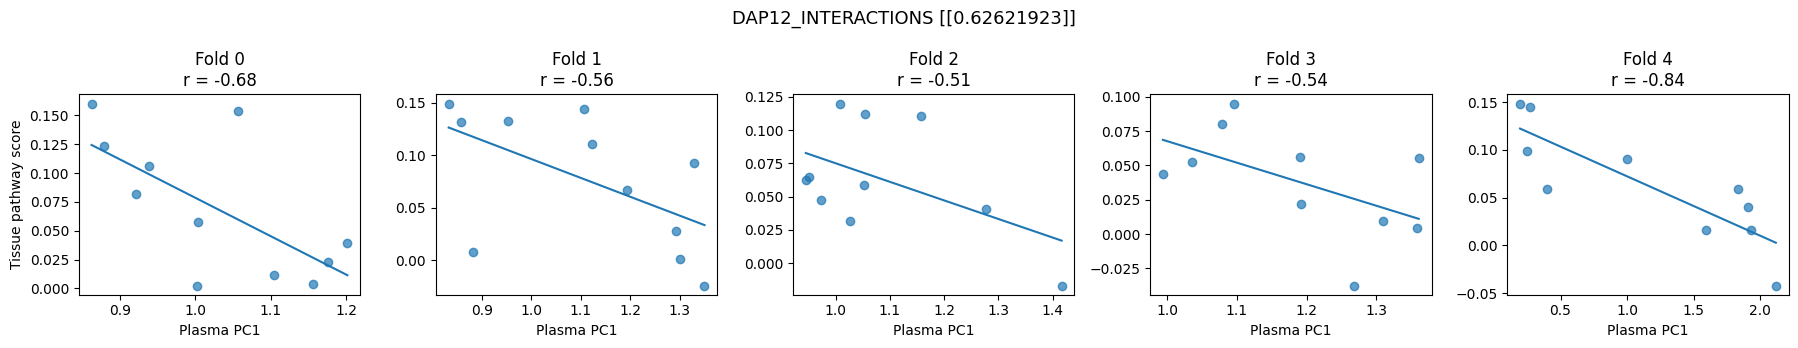

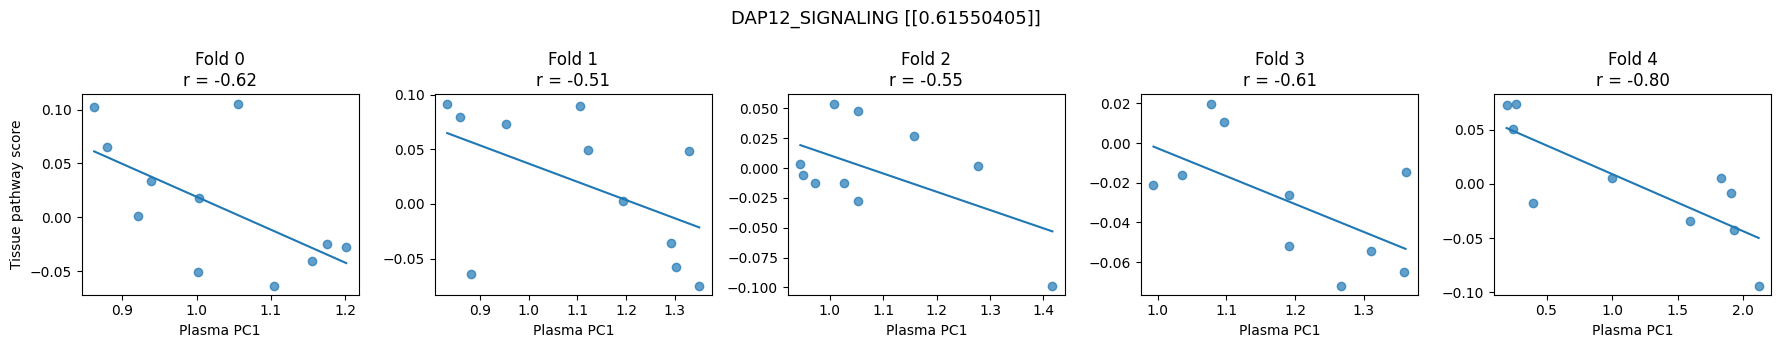

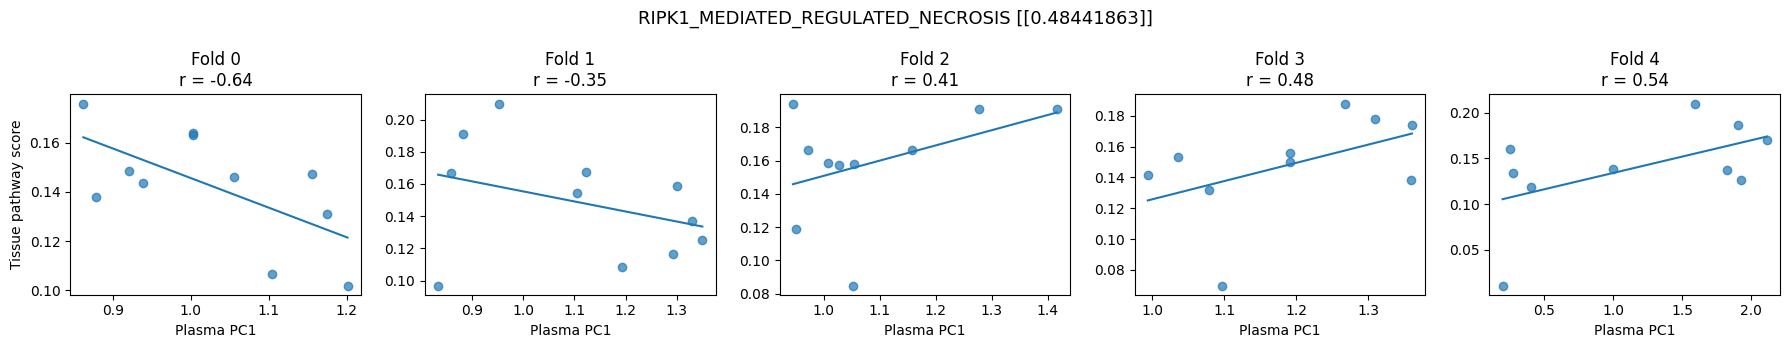

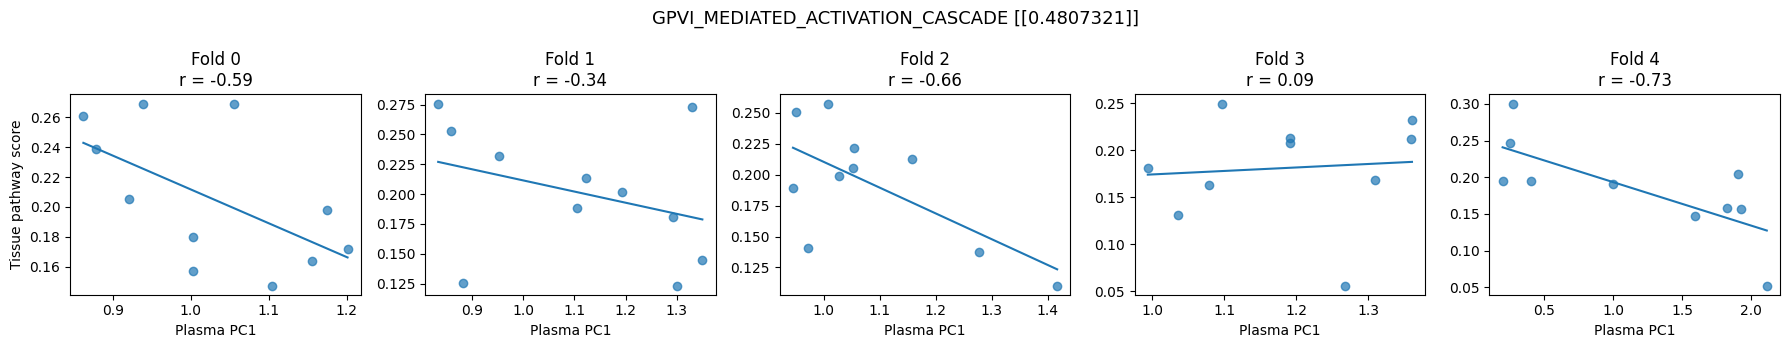

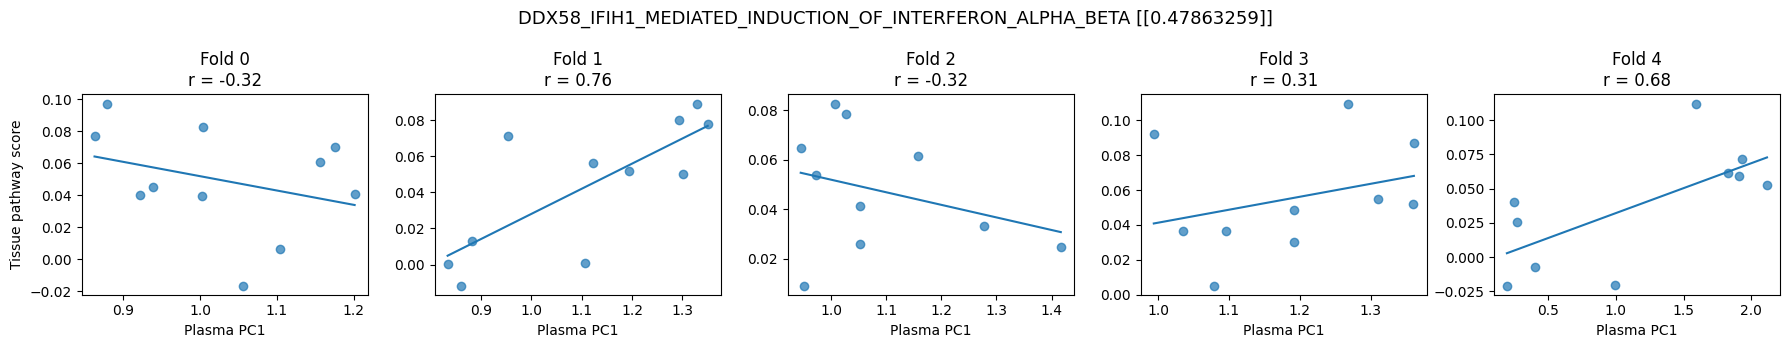

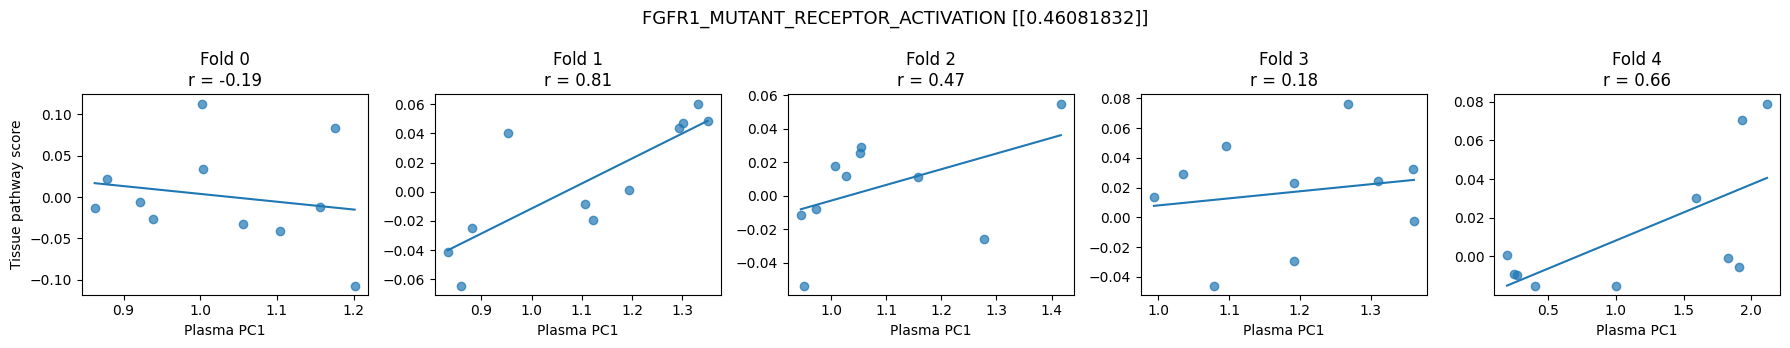

In [127]:
import matplotlib.pyplot as plt
import numpy as np

for pathway in top_pearson_PC1_index:

    pathway_df = cross_plasma_to_tissue[
        (cross_plasma_to_tissue["PC"] == "PC1") &
        (cross_plasma_to_tissue["pathway"] == pathway)
    ]

    fig, axes = plt.subplots(
        1, 5,
        figsize=(18, 3.5),
        sharex=False,
        sharey=False
    )

    for ax, (_, row) in zip(axes, pathway_df.iterrows()):

        fold = row["fold"]

        # Get the actual patient-level data for this fold
        fold_data = plasma_pc_tissue_pathways[
            plasma_pc_tissue_pathways["fold"] == fold
        ]

        x = fold_data["PC1"]
        y = fold_data[pathway]

        ax.scatter(x, y, alpha=0.7)

        # Regression line
        if len(x) >= 3:
            z = np.polyfit(x, y, 1)
            x_line = np.linspace(x.min(), x.max(), 100)
            y_line = z[0] * x_line + z[1]
            ax.plot(x_line, y_line)

        ax.set_title(
            f"Fold {int(fold)}\n"
            f"r = {row['pearson_r']:.2f}"
        )

        ax.set_xlabel("Plasma PC1")

    axes[0].set_ylabel("Tissue pathway score")
    abs_r = pathway_df.agg(pearson_mean_abs_r=("pearson_r", lambda x: x.abs().mean()))

    fig.suptitle(
        f'{pathway.replace("REACTOME_", "")} {(abs_r.values)}',
        fontsize=13
    )

    plt.tight_layout()
    plt.show()

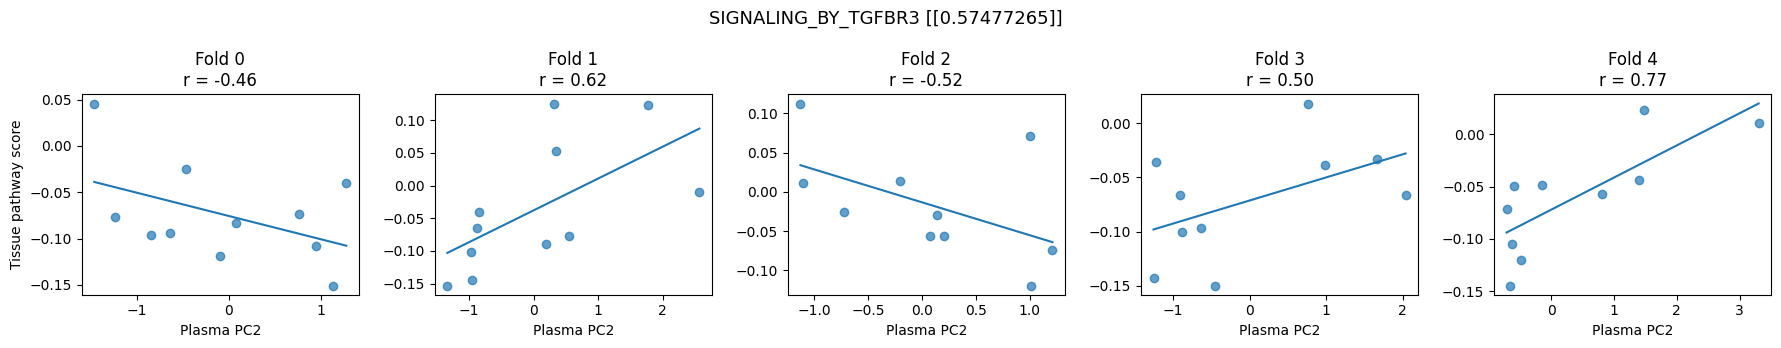

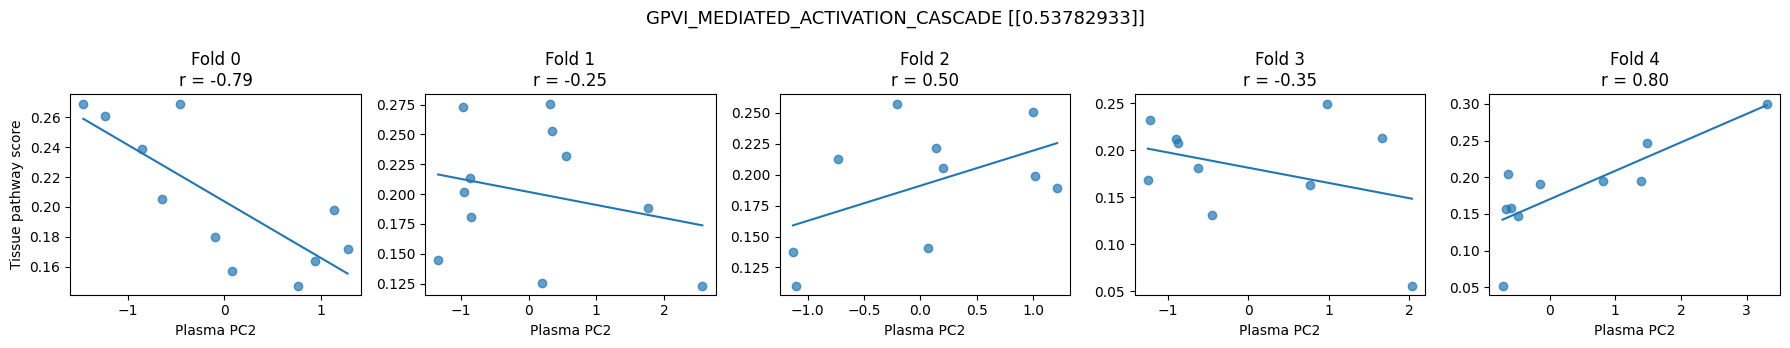

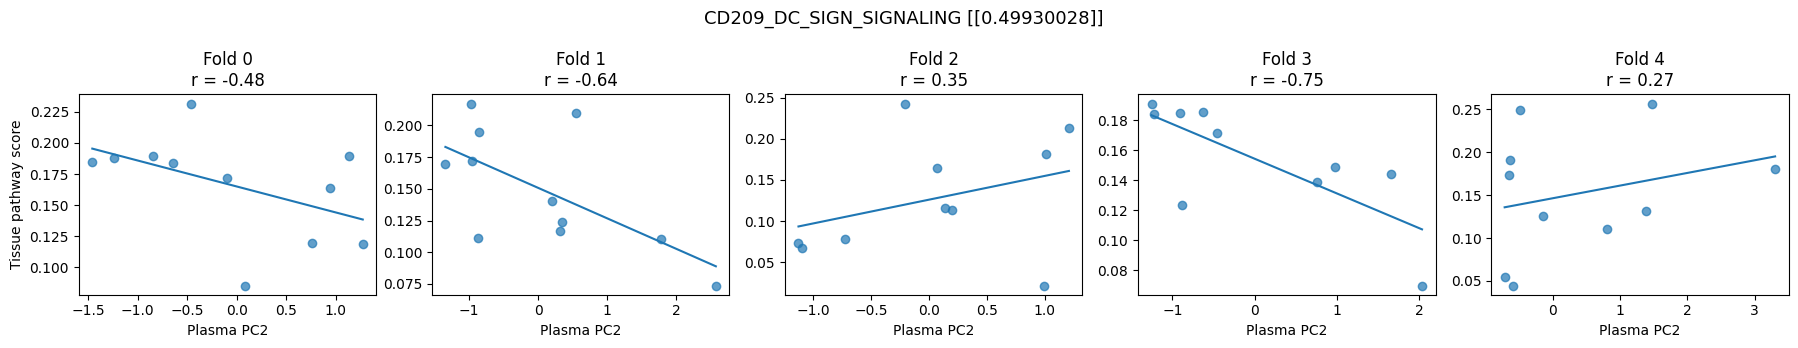

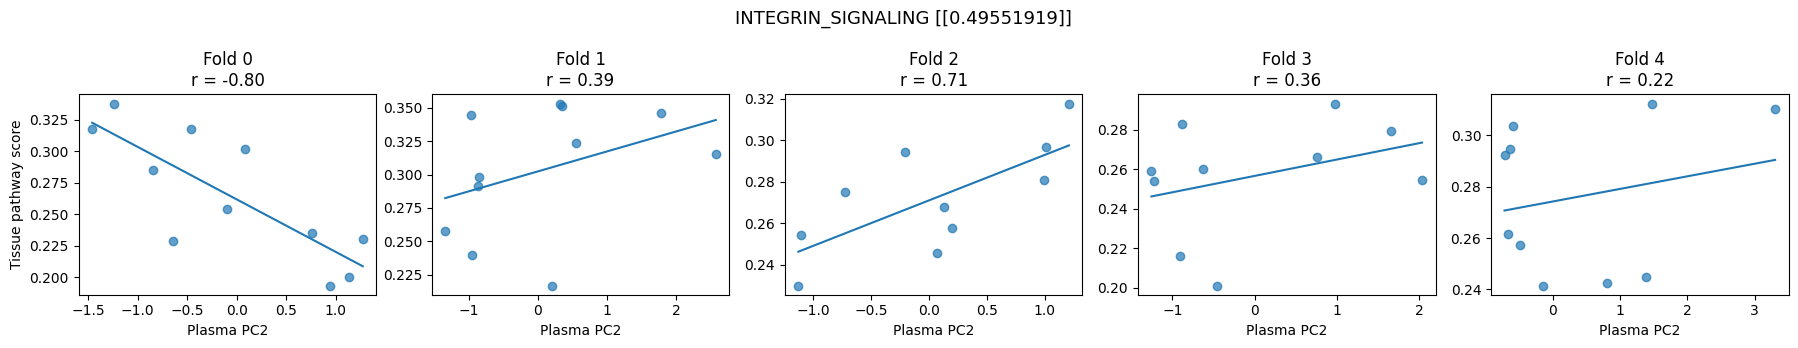

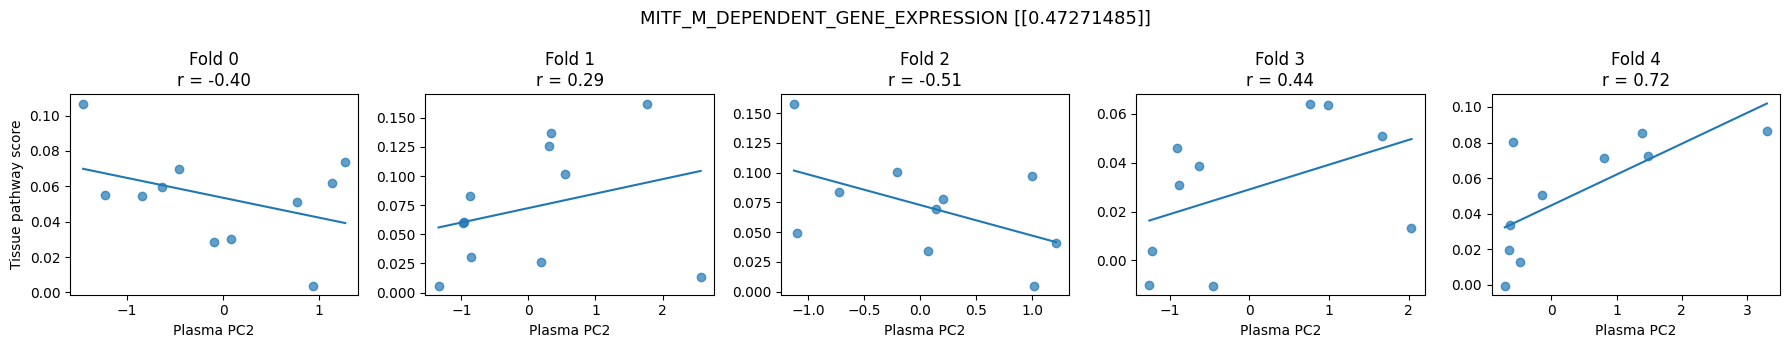

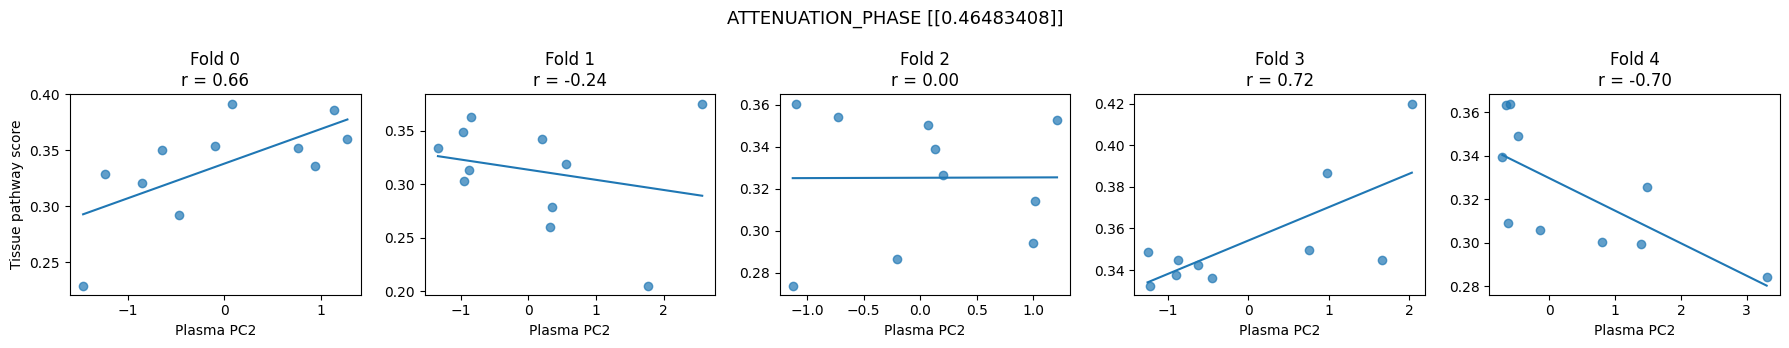

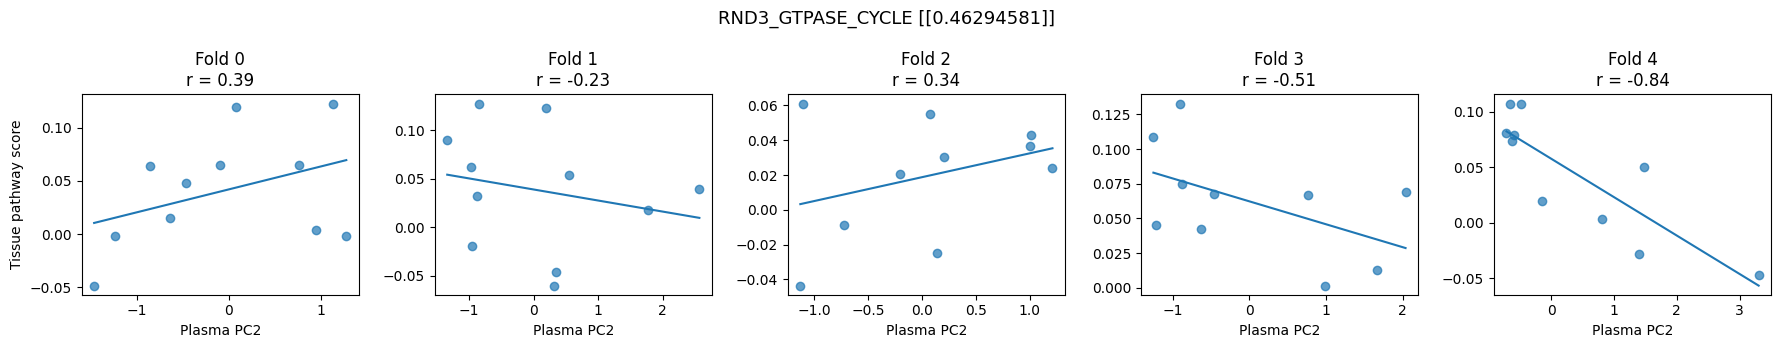

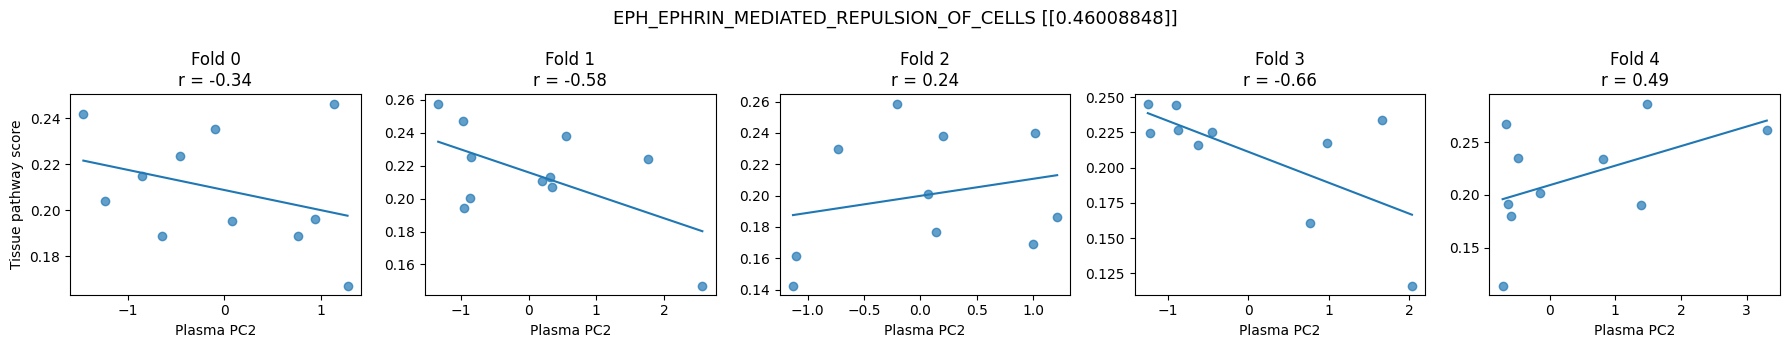

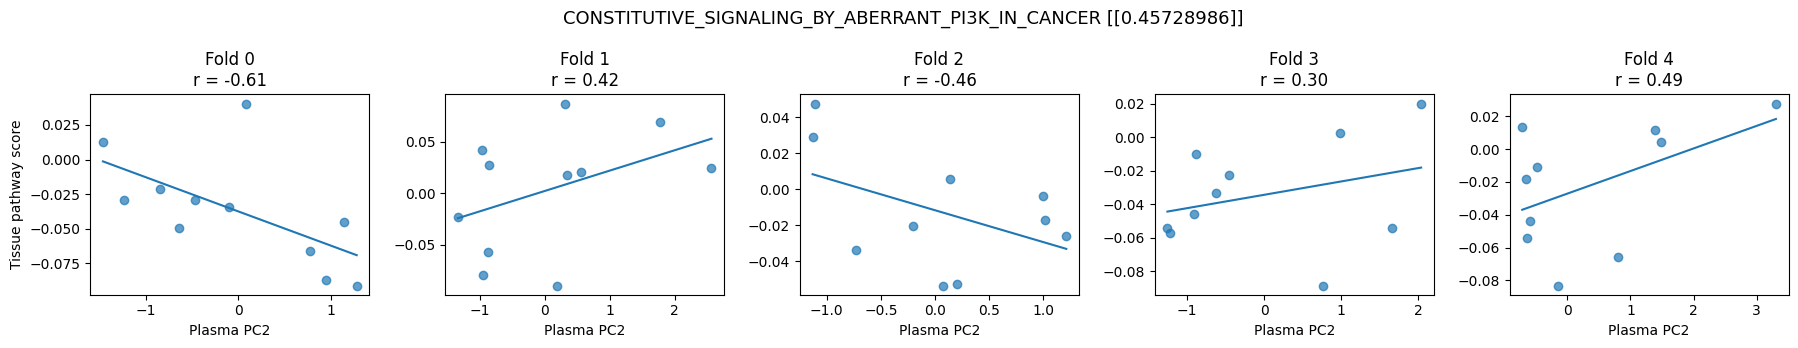

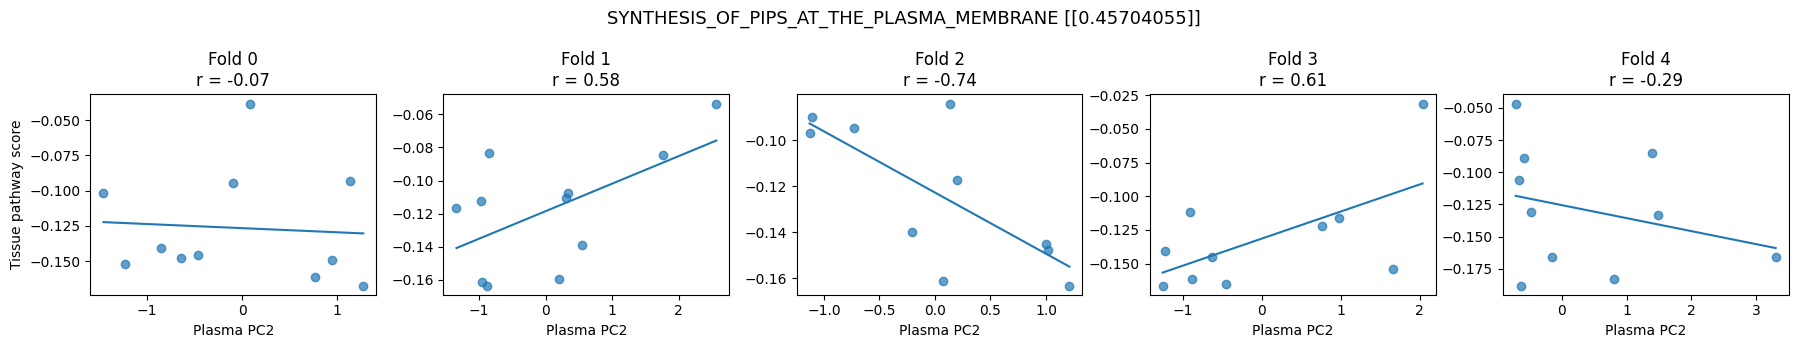

In [128]:
import matplotlib.pyplot as plt
import numpy as np

for pathway in top_pearson_PC2_index:

    pathway_df = cross_plasma_to_tissue[
        (cross_plasma_to_tissue["PC"] == "PC2") &
        (cross_plasma_to_tissue["pathway"] == pathway)
        ]

    fig, axes = plt.subplots(
        1, 5,
        figsize=(18, 3.5),
        sharex=False,
        sharey=False
    )

    for ax, (_, row) in zip(axes, pathway_df.iterrows()):

        fold = row["fold"]

        # Get the actual patient-level data for this fold
        fold_data = plasma_pc_tissue_pathways[
            plasma_pc_tissue_pathways["fold"] == fold
            ]

        x = fold_data["PC2"]
        y = fold_data[pathway]

        ax.scatter(x, y, alpha=0.7)

        # Regression line
        if len(x) >= 3:
            z = np.polyfit(x, y, 1)
            x_line = np.linspace(x.min(), x.max(), 100)
            y_line = z[0] * x_line + z[1]
            ax.plot(x_line, y_line)

        ax.set_title(
            f"Fold {int(fold)}\n"
            f"r = {row['pearson_r']:.2f}"
        )

        ax.set_xlabel("Plasma PC2")

    axes[0].set_ylabel("Tissue pathway score")
    abs_r = pathway_df.agg(pearson_mean_abs_r=("pearson_r", lambda x: x.abs().mean()))

    fig.suptitle(
        f'{pathway.replace("REACTOME_", "")} {(abs_r.values)}',
        fontsize=13
    )

    plt.tight_layout()
    plt.show()

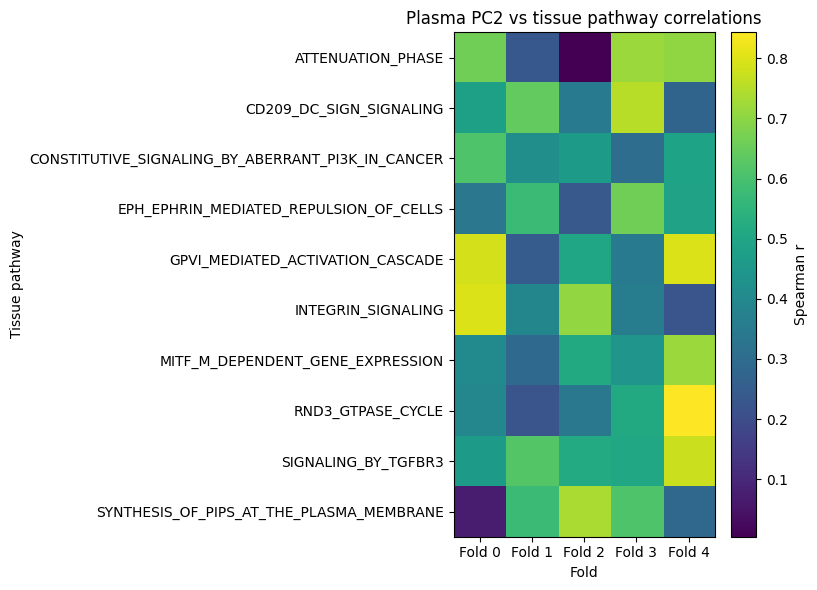

In [129]:
plt.figure(figsize=(8, 6))

plt.imshow(
    plot_df_PC2,
    aspect="auto"
)

plt.xticks(
    range(len(plot_df_PC2.columns)),
    [f"Fold {x}" for x in plot_df_PC2.columns]
)

plt.yticks(
    range(len(plot_df_PC2.index)),
    [
        x.replace("REACTOME_", "")
        for x in plot_df_PC2.index
    ]
)

plt.colorbar(label="Spearman r")

plt.xlabel("Fold")
plt.ylabel("Tissue pathway")
plt.title("Plasma PC2 vs tissue pathway correlations")

plt.tight_layout()
plt.show()

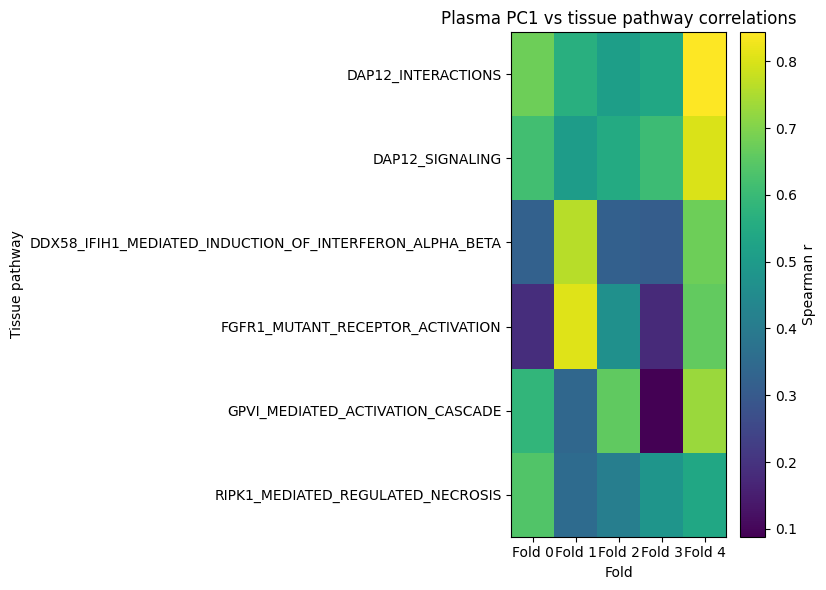

In [130]:
plt.figure(figsize=(8, 6))

plt.imshow(
    plot_df_PC1,
    aspect="auto"
)

plt.xticks(
    range(len(plot_df_PC1.columns)),
    [f"Fold {x}" for x in plot_df_PC1.columns]
)

plt.yticks(
    range(len(plot_df_PC1.index)),
    [
        x.replace("REACTOME_", "")
        for x in plot_df_PC1.index
    ]
)

plt.colorbar(label="Spearman r")

plt.xlabel("Fold")
plt.ylabel("Tissue pathway")
plt.title("Plasma PC1 vs tissue pathway correlations")

plt.tight_layout()
plt.show()

In [131]:
top_pearson = top_pearson_PC1_index.union(top_pearson_PC2_index)
pathway_comp_pc1 = (
    cross_plasma_to_tissue[
        (cross_plasma_to_tissue["PC"] == "PC1")&
        (cross_plasma_to_tissue["pathway"].isin(top_pearson_PC1_index))
    ]
    .groupby("pathway")
    .agg(
        pc_pathway_abs_r=("pearson_r", lambda x: x.abs().mean())
    )
    .reset_index()
)
pathway_comp_pc2 = (
    cross_plasma_to_tissue[
        (cross_plasma_to_tissue["PC"] == "PC2")&
        (cross_plasma_to_tissue["pathway"].isin(top_pearson_PC2_index))
    ]
    .groupby("pathway")
    .agg(
        pc_pathway_abs_r=("pearson_r", lambda x: x.abs().mean())
    )
    .reset_index()
)




pathway_correlations_1 = pathway_correlations[
    pathway_correlations["pathway"].isin(top_pearson)
][["pathway", "pearson_r"]]

pathway_comp= pd.concat(
    [pathway_comp_pc1, pathway_comp_pc2],
    axis=0
)

pathway_comp = pathway_comp.merge(
    pathway_correlations_1,
    on="pathway",
    how="left"
)

pathway_comp = pathway_comp.rename(columns={
    "pc_pathway_abs_r": "PC plasma → tissue pathway |r|",
    "pearson_r": "Plasma pathway ↔ tissue pathway r"
})

print(pathway_comp.head(10))

                                             pathway  \
0                        REACTOME_DAP12_INTERACTIONS   
1                           REACTOME_DAP12_SIGNALING   
2  REACTOME_DDX58_IFIH1_MEDIATED_INDUCTION_OF_INT...   
3          REACTOME_FGFR1_MUTANT_RECEPTOR_ACTIVATION   
4          REACTOME_GPVI_MEDIATED_ACTIVATION_CASCADE   
5         REACTOME_RIPK1_MEDIATED_REGULATED_NECROSIS   
6                         REACTOME_ATTENUATION_PHASE   
7                   REACTOME_CD209_DC_SIGN_SIGNALING   
8  REACTOME_CONSTITUTIVE_SIGNALING_BY_ABERRANT_PI...   
9    REACTOME_EPH_EPHRIN_MEDIATED_REPULSION_OF_CELLS   

   PC plasma → tissue pathway |r|  Plasma pathway ↔ tissue pathway r  
0                        0.626219                                NaN  
1                        0.615504                                NaN  
2                        0.478633                                NaN  
3                        0.460818                                NaN  
4                        0.4

In [132]:
pathway_comp.sort_values(by='PC plasma → tissue pathway |r|',ascending=False).head(20)

,pathway,PC plasma → tissue pathway |r|,Plasma pathway ↔ tissue pathway r
0,REACTOME_DAP12_INTERACTIONS,0.626219,NaN
1,REACTOME_DAP12_SIGNALING,0.615504,NaN
14,REACTOME_SIGNALING_BY_TGFBR3,0.574773,NaN
10,REACTOME_GPVI_MEDIATED_ACTIVATION_CASCADE,0.537829,NaN
7,REACTOME_CD209_DC_SIGN_SIGNALING,0.499300,NaN
11,REACTOME_INTEGRIN_SIGNALING,0.495519,-0.128994
5,REACTOME_RIPK1_MEDIATED_REGULATED_NECROSIS,0.484419,NaN
4,REACTOME_GPVI_MEDIATED_ACTIVATION_CASCADE,0.480732,NaN
2,REACTOME_DDX58_IFIH1_MEDIATED_INDUCTION_OF_INT...,0.478633,NaN
12,REACTOME_MITF_M_DEPENDENT_GENE_EXPRESSION,0.472715,-0.228976


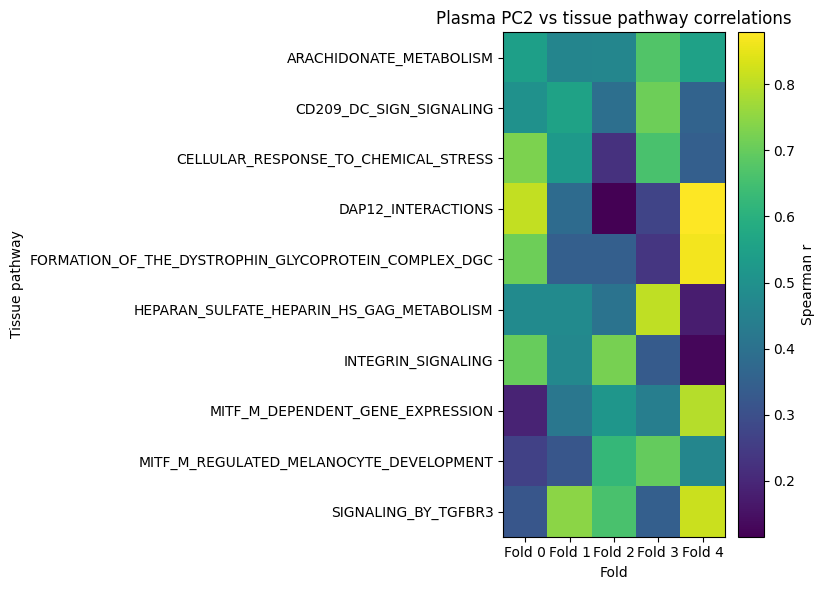

In [168]:
plt.figure(figsize=(8, 6))

plt.imshow(
    plot_df,
    aspect="auto"
)

plt.xticks(
    range(len(plot_df.columns)),
    [f"Fold {x}" for x in plot_df.columns]
)

plt.yticks(
    range(len(plot_df.index)),
    [
        x.replace("REACTOME_", "")
        for x in plot_df.index
    ]
)

plt.colorbar(label="Spearman r")

plt.xlabel("Fold")
plt.ylabel("Tissue pathway")
plt.title("Plasma PC2 vs tissue pathway correlations")

plt.tight_layout()
plt.show()

In [140]:
summary_plasma_to_tissue[
    (summary_plasma_to_tissue["PC"] == "PC2") &
    (summary_plasma_to_tissue["n_folds"] == 5)
].sort_values(['spearman_mean_abs_r'],
    ascending=False
).head(30)

,PC,pathway,pearson_mean_abs_r,pearson_median_abs_r,pearson_min_abs_r,pearson_max_abs_r,spearman_mean_abs_r,spearman_median_abs_r,spearman_min_abs_r,spearman_max_abs_r,n_folds
1468,PC2,REACTOME_SIGNALING_BY_TGFBR3,0.574773,0.516309,0.461192,0.774497,0.577576,0.660606,0.318182,0.818182,5
823,PC2,REACTOME_ARACHIDONATE_METABOLISM,0.434634,0.479960,0.153729,0.569800,0.540000,0.545455,0.463636,0.672727,5
855,PC2,REACTOME_CD209_DC_SIGN_SIGNALING,0.499300,0.481970,0.274181,0.753076,0.503030,0.500000,0.357576,0.709091,5
1024,PC2,REACTOME_FORMATION_OF_THE_DYSTROPHIN_GLYCOPROT...,0.415396,0.253318,0.123416,0.796729,0.500606,0.345455,0.236364,0.866667,5
861,PC2,REACTOME_CELLULAR_RESPONSE_TO_CHEMICAL_STRESS,0.367993,0.401709,0.074735,0.617684,0.496970,0.527273,0.224242,0.727273,5
917,PC2,REACTOME_DAP12_INTERACTIONS,0.400718,0.158422,0.028370,0.884269,0.491515,0.381818,0.115152,0.878788,5
1170,PC2,REACTOME_MITF_M_REGULATED_MELANOCYTE_DEVELOPMENT,0.418732,0.427511,0.127697,0.756171,0.473939,0.466667,0.263636,0.696970,5
1169,PC2,REACTOME_MITF_M_DEPENDENT_GENE_EXPRESSION,0.472715,0.440410,0.290073,0.715812,0.472121,0.442424,0.190909,0.793939,5
1104,PC2,REACTOME_INTEGRIN_SIGNALING,0.495519,0.390553,0.224675,0.797647,0.470909,0.472727,0.127273,0.721212,5
1075,PC2,REACTOME_HEPARAN_SULFATE_HEPARIN_HS_GAG_METABO...,0.411043,0.489249,0.063085,0.578344,0.470303,0.481818,0.175758,0.806061,5


In [129]:
cross_tissue_to_plasma[
    cross_tissue_to_plasma["PC"] == "PC2"
].sort_values(
    ["pearson_fdr",'spearman_r'],
    ascending=True
).head(50)


,PC,pathway,n,pearson_r,pearson_p,spearman_r,spearman_p,fold,pearson_fdr,spearman_fdr
2502,PC2,REACTOME_SIGNALING_BY_VEGF,10,-0.976303,0.000001,-0.842424,0.002220,3,0.000974,0.012567
2902,PC2,REACTOME_CLASS_I_MHC_MEDIATED_ANTIGEN_PROCESSI...,10,-0.971598,0.000003,-0.939394,0.000055,4,0.001012,0.003219
3036,PC2,REACTOME_NERVOUS_SYSTEM_DEVELOPMENT,10,-0.967378,0.000005,-0.830303,0.002940,4,0.001052,0.014406
2940,PC2,REACTOME_DISEASES_OF_SIGNAL_TRANSDUCTION_BY_GR...,10,-0.967011,0.000005,-0.818182,0.003815,4,0.001052,0.016254
1095,PC2,REACTOME_INTERFERON_SIGNALING,11,-0.953240,0.000006,-0.881818,0.000330,1,0.001097,0.006260
2864,PC2,REACTOME_ANTIGEN_PROCESSING_CROSS_PRESENTATION,10,-0.964607,0.000007,-0.769697,0.009222,4,0.001097,0.026624
1703,PC2,REACTOME_GLYCOSAMINOGLYCAN_METABOLISM,10,-0.959713,0.000011,-0.963636,0.000007,2,0.001138,0.001289
412,PC2,REACTOME_ELASTIC_FIBRE_FORMATION,11,-0.946442,0.000010,-0.936364,0.000022,0,0.001138,0.001853
965,PC2,REACTOME_ANTIMICROBIAL_MECHANISM_OF_IFN_STIMUL...,11,-0.942812,0.000014,-0.927273,0.000040,1,0.001138,0.002930
1152,PC2,REACTOME_PLATELET_AGGREGATION_PLUG_FORMATION,11,-0.947603,0.000009,-0.881818,0.000330,1,0.001138,0.006260


In [121]:
cross_tissue_to_plasma.columns

Index(['PC', 'pathway', 'n', 'pearson_r', 'pearson_p', 'spearman_r',
       'spearman_p', 'fold', 'pearson_fdr', 'spearman_fdr'],
      dtype='str')

In [116]:
cross_plasma_to_tissue[
    cross_plasma_to_tissue["PC"] == "PC2"
].sort_values(
    "pearson_r",
    ascending=True
).head(20)

,PC,pathway,n,pearson_r,pearson_p,spearman_r,spearman_p,fold,pearson_fdr,spearman_fdr
7687,PC2,REACTOME_RND2_GTPASE_CYCLE,10,-0.908319,0.000276,-0.939394,0.000055,4,0.593317,0.262128
917,PC2,REACTOME_DAP12_INTERACTIONS,11,-0.884269,0.000302,-0.809091,0.002559,0,0.593317,0.510981
918,PC2,REACTOME_DAP12_SIGNALING,11,-0.867467,0.000541,-0.809091,0.002559,0,0.709869,0.510981
7688,PC2,REACTOME_RND3_GTPASE_CYCLE,10,-0.843226,0.002177,-0.781818,0.007547,4,0.777489,0.535090
2617,PC2,REACTOME_GLUCOSE_METABOLISM,11,-0.834927,0.001384,-0.709091,0.014552,1,0.777489,0.612431
1014,PC2,REACTOME_FLT3_SIGNALING,11,-0.824939,0.001775,-0.836364,0.001333,0,0.777489,0.476917
1430,PC2,REACTOME_SIGNALING_BY_CSF1_M_CSF_IN_MYELOID_CELLS,11,-0.823350,0.001844,-0.881818,0.000330,0,0.777489,0.338028
1335,PC2,REACTOME_REGULATION_OF_SIGNALING_BY_CBL,11,-0.797743,0.003260,-0.818182,0.002083,0,0.873036,0.510981
1104,PC2,REACTOME_INTEGRIN_SIGNALING,11,-0.797647,0.003267,-0.700000,0.016471,0,0.873036,0.641716
7320,PC2,REACTOME_FORMATION_OF_THE_DYSTROPHIN_GLYCOPROT...,10,-0.796729,0.005797,-0.866667,0.001174,4,0.931096,0.461787
